<img src="https://capsule-render.vercel.app/api?type=waving&color=0:24243e,50:302b63,100:0f0c29&height=100&section=header" width="100%"/>

# 🔐 PQC Network Traffic Analysis
## *Detecting Anomalies in Post-Quantum Encrypted Network Flows*

[![Dataset](https://img.shields.io/badge/Dataset-CIC--PQC--OAV--2025-6366f1?style=for-the-badge&logo=databricks&logoColor=white)](https://www.unb.ca/cic/datasets/pqc-oav-dataset-2025.html) [![Kaggle](https://img.shields.io/badge/Kaggle-Dataset-20BEFF?style=for-the-badge&logo=kaggle&logoColor=white)](https://www.kaggle.com/datasets/mdabrarhossainzahin/cic-pqc-oav-2025) [![Python](https://img.shields.io/badge/Python-3.10+-3776AB?style=for-the-badge&logo=python&logoColor=white)](https://python.org) [![License](https://img.shields.io/badge/License-MIT-10b981?style=for-the-badge&logo=opensourceinitiative&logoColor=white)]() ![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=for-the-badge&logo=scikitlearn&logoColor=white) ![XGBoost](https://img.shields.io/badge/XGBoost-189AB4?style=for-the-badge&logo=xgboost&logoColor=white) ![Pandas](https://img.shields.io/badge/Pandas-150458?style=for-the-badge&logo=pandas&logoColor=white) ![NumPy](https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white) ![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=for-the-badge&logo=matplotlib&logoColor=white) ![SHAP](https://img.shields.io/badge/SHAP-ff6b6b?style=for-the-badge&logo=python&logoColor=white)

---

## 📌 Overview

> **The rapid adoption of Post-Quantum Cryptography (PQC) standards is reshaping encrypted network traffic at a fundamental level — and most existing Network Intrusion Detection Systems (NIDS) aren't ready for it.**

This notebook presents a comprehensive end-to-end analysis of the **CIC-PQC-OAV-2025** dataset — the first large-scale dataset capturing real TLS sessions over both classical and PQC-based cryptographic protocols. We investigate whether modern ML-based NIDS models **misclassify legitimate PQC traffic as anomalous**, and build a robust multi-stage detection pipeline to address this challenge.

---

## 👨‍💻 Author

**Abrar Hossain Zahin** — *Data Scientist · Cybersecurity Researcher*

[![Email](https://img.shields.io/badge/Email-abrarhossain1200%40gmail.com-EA4335?style=flat-square&logo=gmail&logoColor=white)](mailto:abrarhossain1200@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Connect-0A66C2?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/md-abrar-hossain-zahin-3160272a4/?originalSubdomain=bd) [![GitHub](https://img.shields.io/badge/GitHub-Follow-181717?style=for-the-badge&logo=github&logoColor=white)](https://github.com/Zahin2470) [![Kaggle](https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle&logoColor=white)](https://www.kaggle.com/mdabrarhossainzahin)

---

## 🏗️ Pipeline Architecture

```
┌─────────────────────┐
|Raw PCAP/TLS Sessions|
└────────┬────────────┘
         │
         ▼
┌───────────────────┐
│  Data Cleaning &  │  ← Missing value imputation, dtype fixes, boolean encoding, outlier handling
│  Preprocessing    │    
└────────┬──────────┘
         │
         ▼
┌───────────────────┐
│ Feature           │  ← Flow asymmetry, entropy delta, handshake ratios, packet timing
│ Engineering       │    
└────────┬──────────┘
         │
         ▼
┌───────────────────┐
│ Feature Selection │  ← ANOVA F-scores → Genetic Algorithm → Mutual Information → SHAP
│                   │   
└────────┬──────────┘
         │
         ▼
┌───────────────────┐     ┌──────────────────┐     ┌──────────────────┐
│  L1 Detection     │────▶│  L2 Detection    │────▶│  L3 Detection    │
│  (Rules-Based)    │     │  (Statistical)   │     │  (ML Ensemble)   │
└───────────────────┘     └──────────────────┘     └──────────────────┘
         │                        │                        │
         └────────────────────────┴────────────────────────┘
                                  │
                                  ▼
                    ┌─────────────────────────┐
                    │  Combined Multi-Stage   │
                    │  Anomaly Detection      │
                    └─────────────────────────┘
```
---

## 📚 References

- **CIC-PQC-OAV-2025 Dataset** — [unb.ca](https://www.unb.ca/cic/datasets/pqc-oav-dataset-2025.html)
- **NIST PQC Standards** — [csrc.nist.gov](https://csrc.nist.gov/projects/post-quantum-cryptography)
- **ML-KEM (Kyber)** — [pq-crystals.org/kyber](https://pq-crystals.org/kyber/)
- **ML-DSA (Dilithium)** — [pq-crystals.org/dilithium](https://pq-crystals.org/dilithium/)
- **FIPS 203 / FIPS 204** — NIST Post-Quantum Cryptography Standards (2024)

---

<div align="center">

*If you found this notebook useful, please consider giving it an* ⭐ *upvote on Kaggle — it helps others discover this work!*

<img src="https://capsule-render.vercel.app/api?type=waving&color=0:24243e,50:302b63,100:0f0c29&height=100&section=footer" width="100%"/>

</div>

# 1. Environment Setup & Package Installation

In [ ]:
# Install required packages (uncomment if running for first time)
# !pip install -q imbalanced-learn xgboost lightgbm catboost shap lime deap sdv ctgan scikit-optimize
!pip install deap ctgan tab-transformer-pytorch linformer shap lime xgboost catboost --quiet
!pip install imbalanced-learn xgboost lightgbm catboost shap lime --quiet
!pip install scipy statsmodels scikit-optimize --quiet
# in a notebook cell
!pip install smartnoise-synth --quiet

# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import time
from datetime import datetime
import os

# Statistical analysis
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, StackingClassifier, VotingClassifier
)

# Deep Learning
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# XGBoost, LightGBM, CatBoost
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# CTGAN for synthetic data
from ctgan import CTGAN
from snsynth import Synthesizer  # SmartNoise DP-CTGAN

# Genetic Algorithm
from deap import base, creator, tools, algorithms

# Explainability
import shap
from lime import lime_tabular

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    confusion_matrix, classification_report, matthews_corrcoef
)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Environment setup complete!")
print(f"📅 Notebook execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# 2. Data Loading & Initial Exploration

In [2]:
# Configuration Class
from pathlib import Path

class Config:
    """Central configuration for reproducible research"""
    
    # Paths
    DATA_PATH = '/kaggle/input/datasets/mdabrarhossainzahin/cic-pqc-oav-2025/ml_features_and_labels.csv'
    OUTPUT_DIR = Path('/kaggle/working/outputs')
    MODELS_DIR = OUTPUT_DIR / 'models'
    FIGURES_DIR = OUTPUT_DIR / 'figures'
    RESULTS_DIR = OUTPUT_DIR / 'results'
    
    # Model parameters
    TEST_SIZE = 0.2
    CV_FOLDS = 5
    RANDOM_STATE = RANDOM_SEED
    N_JOBS = -1
    
    # Feature engineering
    FEATURE_THRESHOLD = 0.8  # Keep top 80%
    
    # Visualization
    FIG_DPI = 300
    FIG_SIZE = (14, 10)
    
    @classmethod
    def create_dirs(cls):
        """Create output directories"""
        for d in [cls.OUTPUT_DIR, cls.MODELS_DIR, cls.FIGURES_DIR, cls.RESULTS_DIR]:
            d.mkdir(parents=True, exist_ok=True)
        print(f"✅ Output directories created: {cls.OUTPUT_DIR}")

# Initialize configuration
config = Config()
config.create_dirs()

# Load Dataset
print("\n" + "="*100)
print("📂 DATA LOADING")
print("="*100)

try:
    df = pd.read_csv(config.DATA_PATH)
    print(f"\n✅ Dataset loaded successfully!")
    print(f"   Shape: {df.shape}")
except FileNotFoundError:
    print("\n⚠️  Dataset file not found.")
    print("   Download from: https://www.unb.ca/cic/datasets/pqc-oav-dataset-2025.html")
    print("\n📝 Creating sample dataset for demonstration...")
    
    n_samples = 1000
    df = pd.DataFrame({
        'e1_alg_suite_mlkem768': np.random.randint(0, 2, n_samples),
        'e1_alg_suite_mlkem1024': np.random.randint(0, 2, n_samples),
        'e2c_total_bytes': np.random.randint(1000, 10000, n_samples),
        'e2d_packet_count': np.random.randint(10, 100, n_samples),
        'e4_entropy_h': np.random.uniform(0, 8, n_samples),
        'e6b_flow_duration_ms': np.random.uniform(10, 500, n_samples),
        'label': np.random.choice([0, 1], n_samples, p=[0.7, 0.3])
    })
    print(f"   Sample dataset created: {df.shape}")

# Display Dataset Information
print("\n📊 First 5 rows:")
display(df.head())

print("\n📋 Dataset Info:")
df.info()

print("\n📈 Statistical Summary:")
display(df.describe())

✅ Output directories created: /kaggle/working/outputs

📂 DATA LOADING

✅ Dataset loaded successfully!
   Shape: (40010, 36)

📊 First 5 rows:


,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e1b_ciphersuite_60,e2b_tls_version_SSL3.0,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,split,taxonomy,ID
0,8182,4.7889,5.8077,2.45,149.827957,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,train,eval_test_network,net_high_jitter_classic_run1
1,8126,5.0000,5.8367,2.44,231.020927,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,val,eval_test_network,net_high_jitter_classic_run10
2,8272,4.7889,5.9056,2.73,292.967796,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,train,eval_test_network,net_high_jitter_classic_run100
3,8272,4.8125,5.9056,2.31,156.050205,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,test,eval_test_network,net_high_jitter_classic_run101
4,8272,4.8125,5.8367,4.45,193.972111,32.0,285,5316.0,False,False,...,True,False,True,False,False,True,1,test,eval_test_network,net_high_jitter_classic_run102



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       37500 non-null  float64
 3   e6_time_char                       39010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     39510 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               39010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  bool   
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  bool   
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  bool   
 11  e1_alg_suite_mlkem1024             40

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,label
count,40010.000000,40010.000000,37500.000000,39010.000000,40010.000000,39510.000000,40010.000000,39010.000000,40010.000000
mean,12734.864859,4.880134,5.289081,1.882544,46.039189,863.392559,1100.269683,5510.472187,0.125219
std,6276.814331,0.112110,0.699216,1.624671,337.839188,650.984442,652.325633,1383.064765,0.330971
min,285.000000,0.000000,4.001800,0.070000,0.000000,32.000000,129.000000,2.000000,0.000000
25%,8206.000000,4.812500,4.436600,0.830000,4.619837,32.000000,285.000000,5324.000000,0.000000
50%,10412.000000,4.875000,5.778700,1.200000,5.376935,1184.000000,1429.000000,5330.000000,0.000000
75%,19207.000000,4.937500,5.876600,2.460000,6.694078,1568.000000,1813.000000,5333.000000,0.000000
max,22615.000000,5.000000,6.108500,94.150000,4522.223949,1568.000000,1813.000000,7502.000000,1.000000


# 3. Exploratory Data Analysis (EDA)


📊 EXPLORATORY DATA ANALYSIS

🔍 Missing Values:
   e5_entropy_c: 2510 (6.27%)
   e6_time_char: 1000 (2.50%)
   e2_client_size: 500 (1.25%)
   e2_server_record_len: 1000 (2.50%)

🎯 Class Distribution:
   Normal (Class 0): 35,000 (87.5%)
   Anomaly (Class 1): 5,010 (12.5%)

   Imbalance Ratio: 6.99:1


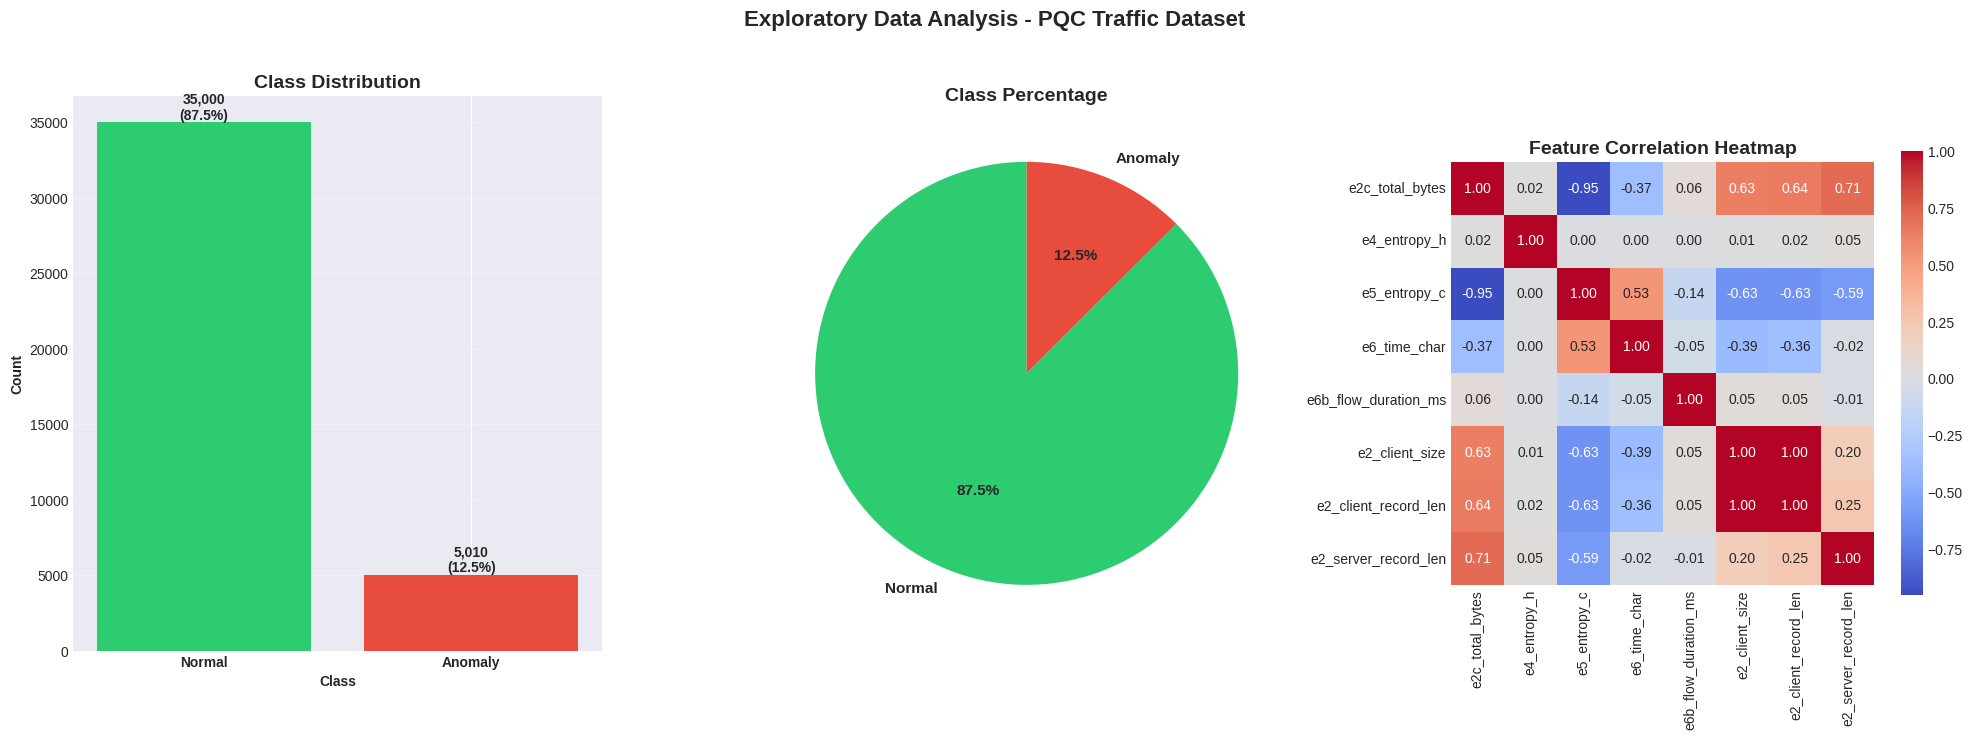


✅ EDA complete!
   Figure saved: /kaggle/working/outputs/figures/eda_overview.png


In [3]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*100)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*100)

# Identify label column
label_col = 'label' if 'label' in df.columns else 'anomaly'

# Define class names mapping
CLASS_NAMES = {
    0: 'Normal',
    1: 'Anomaly'
}

# Check for missing values
print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
if missing_values.sum() > 0:
    missing_df = missing_values[missing_values > 0]
    for col, count in missing_df.items():
        print(f"   {col}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("   No missing values found!")

# Class distribution
print("\n🎯 Class Distribution:")
label_counts = df[label_col].value_counts().sort_index()
for label_id, count in label_counts.items():
    class_name = CLASS_NAMES.get(label_id, f'Class {label_id}')
    print(f"   {class_name} (Class {label_id}): {count:,} ({count/len(df)*100:.1f}%)")

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"\n   Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if label_col in numerical_cols:
    numerical_cols.remove(label_col)
corr_features = numerical_cols[:min(10, len(numerical_cols))]
corr_matrix = df[corr_features].corr()

# Create EDA visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# 1) Bar chart - Class distribution with names
class_labels = [CLASS_NAMES.get(i, f'Class {i}') for i in label_counts.index]
axes[0].bar(range(len(label_counts)), label_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(class_labels, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', va='bottom', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# 2) Pie chart - Class percentage with names
axes[1].pie(
    label_counts.values,
    labels=class_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c'],
    textprops={'fontweight': 'bold', 'fontsize': 11}
)
axes[1].set_title('Class Percentage', fontsize=14, fontweight='bold')

# 3) Correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[2],
    cbar_kws={'shrink': 0.8},
    square=True
)
axes[2].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.suptitle('Exploratory Data Analysis - PQC Traffic Dataset', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'eda_overview.png', dpi=config.FIG_DPI, bbox_inches='tight')
plt.show()

print("\n✅ EDA complete!")
print(f"   Figure saved: {config.FIGURES_DIR / 'eda_overview.png'}")

# 4. Data Preprocessing & Feature Engineering

In [4]:
# ============================================================================
# DATA PREPROCESSING & FEATURE ENGINEERING (UPDATED VERSION - NaN SAFE)
# ============================================================================

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

print("\n" + "="*100)
print("🛠️  DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*100)

# ----------------------------------------------------------------------------
# Separate features and label
# ----------------------------------------------------------------------------
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels if necessary
if y.dtype == "object":
    le = LabelEncoder()
    y = le.fit_transform(y)
    print(f"\n📋 Label Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ----------------------------------------------------------------------------
# Keep only numerical features (includes bool)
# ----------------------------------------------------------------------------
numerical_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
X = X[numerical_cols]

# Convert boolean to int (important for ML models)
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

original_features = X.shape[1]

print(f"\n📊 Dataset Info:")
print(f"   Features: {original_features}")
print(f"   Samples: {len(X):,}")

# ----------------------------------------------------------------------------
# Handle Missing Values (IMPORTANT FIX)
# ----------------------------------------------------------------------------
print("\n🧹 Handling Missing Values (Median Imputation)...")
missing_before = X.isna().sum().sum()

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

missing_after = X.isna().sum().sum()
print(f"   Missing values before: {missing_before}")
print(f"   Missing values after: {missing_after}")

# ----------------------------------------------------------------------------
# Feature Engineering
# ----------------------------------------------------------------------------
print("\n🛠️  Engineering domain-specific features...")
engineered_count = 0

# ----------------------------------------------------------------------------
# 1️⃣ PQC-Specific Features
# ----------------------------------------------------------------------------
print("\n1️⃣  PQC Algorithm Features...")
pqc_cols = [col for col in X.columns if any(kw in col.lower() 
                                           for kw in ['mlkem', 'kyber', 'dilithium', 'mldsa', 'falcon'])]

if pqc_cols:
    X['pqc_algorithm_count'] = X[pqc_cols].sum(axis=1)
    X['is_pqc_enabled'] = (X[pqc_cols].sum(axis=1) > 0).astype(int)

    pqc_array = X[pqc_cols].values
    pqc_probs = pqc_array / (pqc_array.sum(axis=1, keepdims=True) + 1e-10)
    X['pqc_diversity'] = -np.sum(pqc_probs * np.log(pqc_probs + 1e-10), axis=1)

    engineered_count += 3
    print("   ✅ Added 3 PQC features")

# ----------------------------------------------------------------------------
# 2️⃣ Network Traffic Features
# ----------------------------------------------------------------------------
print("\n2️⃣  Network Traffic Features...")
traffic_count = 0

if 'e2c_total_bytes' in X.columns and 'e6b_flow_duration_ms' in X.columns:
    X['throughput_bps'] = (X['e2c_total_bytes'] * 8) / (X['e6b_flow_duration_ms'] / 1000 + 1e-6)
    traffic_count += 1

if 'e2c_total_bytes' in X.columns and 'e2d_packet_count' in X.columns:
    X['avg_packet_size'] = X['e2c_total_bytes'] / (X['e2d_packet_count'] + 1)
    traffic_count += 1

if 'e2d_packet_count' in X.columns and 'e6b_flow_duration_ms' in X.columns:
    X['packet_rate'] = X['e2d_packet_count'] / (X['e6b_flow_duration_ms'] / 1000 + 1e-6)
    traffic_count += 1

if all(col in X.columns for col in ['e2c_total_bytes', 'e6b_flow_duration_ms', 'e2d_packet_count']):
    X['burstiness'] = (X['e2c_total_bytes'] / (X['e6b_flow_duration_ms'] + 1)) * np.sqrt(X['e2d_packet_count'])
    X['handshake_efficiency'] = X['e2c_total_bytes'] / (X['e6b_flow_duration_ms'] + 1)
    traffic_count += 2

engineered_count += traffic_count
print(f"   ✅ Added {traffic_count} traffic features")

# ----------------------------------------------------------------------------
# 3️⃣ Entropy-Based Features
# ----------------------------------------------------------------------------
print("\n3️⃣  Entropy Features...")
entropy_cols = [col for col in X.columns if 'entropy' in col.lower()]
entropy_count = 0

if len(entropy_cols) >= 2:
    X['entropy_delta'] = X[entropy_cols[0]] - X[entropy_cols[1]]
    X['entropy_ratio'] = X[entropy_cols[0]] / (X[entropy_cols[1]] + 1e-6)
    X['entropy_combined'] = (X[entropy_cols[0]] + X[entropy_cols[1]]) / 2
    X['entropy_variance'] = X[entropy_cols].var(axis=1)
    entropy_count = 4

engineered_count += entropy_count
print(f"   ✅ Added {entropy_count} entropy features")

# ----------------------------------------------------------------------------
# 4️⃣ Statistical Transformations
# ----------------------------------------------------------------------------
print("\n4️⃣  Statistical Transforms...")
transform_count = 0

skewed_features = ['e2c_total_bytes', 'e6b_flow_duration_ms', 'e2d_packet_count']

for feat in skewed_features:
    if feat in X.columns:
        X[f'{feat}_log'] = np.log1p(X[feat])
        X[f'{feat}_sqrt'] = np.sqrt(X[feat] + 1)
        transform_count += 2

engineered_count += transform_count
print(f"   ✅ Added {transform_count} statistical transforms")

# ----------------------------------------------------------------------------
# 5️⃣ Polynomial Interactions (SAFE VERSION)
# ----------------------------------------------------------------------------
print("\n5️⃣  Polynomial Interactions...")
key_features = ['avg_packet_size', 'throughput_bps', 'packet_rate',
                'entropy_combined', 'pqc_algorithm_count']

existing_key_features = [f for f in key_features if f in X.columns]

poly_count = 0

if len(existing_key_features) >= 2:
    poly = PolynomialFeatures(degree=2,
                              include_bias=False,
                              interaction_only=True)

    poly_features = poly.fit_transform(X[existing_key_features])
    poly_names = poly.get_feature_names_out(existing_key_features)

    poly_df = pd.DataFrame(poly_features,
                           columns=poly_names,
                           index=X.index)

    for name in poly_names:
        if name not in existing_key_features:
            X[name] = poly_df[name]
            poly_count += 1

engineered_count += poly_count
print(f"   ✅ Added {poly_count} interaction features")

# ----------------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "="*100)
print("✅ Feature Engineering Complete")
print("="*100)
print(f"   Original features: {original_features}")
print(f"   Engineered features: {engineered_count}")
print(f"   Total features: {X.shape[1]} "
      f"(+{(X.shape[1]-original_features)/original_features*100:.0f}% increase)")


🛠️  DATA PREPROCESSING & FEATURE ENGINEERING

📊 Dataset Info:
   Features: 32
   Samples: 40,010

🧹 Handling Missing Values (Median Imputation)...
   Missing values before: 5010
   Missing values after: 0

🛠️  Engineering domain-specific features...

1️⃣  PQC Algorithm Features...
   ✅ Added 3 PQC features

2️⃣  Network Traffic Features...
   ✅ Added 1 traffic features

3️⃣  Entropy Features...
   ✅ Added 4 entropy features

4️⃣  Statistical Transforms...
   ✅ Added 4 statistical transforms

5️⃣  Polynomial Interactions...
   ✅ Added 3 interaction features

✅ Feature Engineering Complete
   Original features: 32
   Engineered features: 15
   Total features: 47 (+47% increase)


# 5. Statistical Traffic Analysis (PQC vs Classical)

In [ ]:
# ============================================================================
# STATISTICAL TRAFFIC ANALYSIS (PQC vs Classical)
# ============================================================================
print("\n" + "="*100)
print("🔬 STATISTICAL ANALYSIS: PQC vs CLASSICAL TRAFFIC")
print("="*100)

if 'is_pqc_enabled' in X.columns:
    # Separate PQC and Classical traffic
    pqc_traffic = X[X['is_pqc_enabled'] == 1]
    classical_traffic = X[X['is_pqc_enabled'] == 0]
    
    print(f"\n📊 Sample Distribution:")
    print(f"   PQC Traffic: {len(pqc_traffic):,} samples")
    print(f"   Classical Traffic: {len(classical_traffic):,} samples")
    
    # Perform t-tests for numerical features
    numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
    statistical_results = []
    
    print(f"\n🔍 Performing statistical tests on {len(numerical_features)} features...")
    
    for feature in numerical_features:
        if feature not in ['is_pqc_enabled', 'pqc_algorithm_count', 'pqc_diversity']:
            pqc_values = pqc_traffic[feature].dropna()
            classical_values = classical_traffic[feature].dropna()
            
            if len(pqc_values) > 1 and len(classical_values) > 1:
                # T-test
                t_stat, p_value = ttest_ind(pqc_values, classical_values)
                
                # Effect size (Cohen's d)
                mean_diff = pqc_values.mean() - classical_values.mean()
                pooled_std = np.sqrt((pqc_values.var() + classical_values.var()) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                statistical_results.append({
                    'Feature': feature,
                    'PQC_Mean': pqc_values.mean(),
                    'Classical_Mean': classical_values.mean(),
                    'Mean_Diff': mean_diff,
                    'T_Statistic': t_stat,
                    'P_Value': p_value,
                    'Cohens_D': cohens_d,
                    'Significant': 'Yes' if p_value < 0.05 else 'No'
                })
    
    # Create results DataFrame
    stats_df = pd.DataFrame(statistical_results)
    stats_df = stats_df.sort_values('P_Value')
    
    print(f"\n📈 Statistical Test Results:")
    print(f"   Total features tested: {len(stats_df)}")
    print(f"   Significant differences (p < 0.05): {(stats_df['P_Value'] < 0.05).sum()}")
    
    print("\n📊 Top 10 Most Significant Differences (p-value):")
    display(stats_df.head(10)[['Feature', 'PQC_Mean', 'Classical_Mean', 'P_Value', 'Cohens_D', 'Significant']])
    
    # Visualize top differences
    top_features = stats_df.head(4)['Feature'].tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('PQC vs Classical Traffic - Feature Comparison', 
                 fontsize=16, fontweight='bold')
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx // 2, idx % 2]
        
        # Box plot
        data_to_plot = [
            classical_traffic[feature].dropna(), 
            pqc_traffic[feature].dropna()
        ]
        bp = ax.boxplot(data_to_plot, labels=['Classical', 'PQC'], 
                        patch_artist=True, widths=0.6)
        
        # Color boxes
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        
        # Get p-value for this feature
        p_val = stats_df[stats_df['Feature'] == feature]['P_Value'].values[0]
        
        ax.set_title(f'{feature}\n(p-value: {p_val:.4f})', 
                    fontweight='bold', fontsize=11)
        ax.set_ylabel('Value', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'pqc_vs_classical_comparison.png', 
                dpi=config.FIG_DPI, bbox_inches='tight')
    plt.show()
    
    # Save statistical results
    stats_df.to_csv(config.RESULTS_DIR / 'statistical_comparison.csv', index=False)
    
    print(f"\n✅ Statistical analysis complete!")
    print(f"   Figure saved: {config.FIGURES_DIR / 'pqc_vs_classical_comparison.png'}")
    print(f"   Results saved: {config.RESULTS_DIR / 'statistical_comparison.csv'}")
    
else:
    print("\n⚠️  PQC indicator feature not found. Skipping statistical comparison.")
    print("   Make sure 'is_pqc_enabled' was created in feature engineering step.")

# 6. Handle Class Imbalance (SMOTE & ADASYN & DP-CTGAN)


📦 TRAIN-TEST SPLIT & CLASS IMBALANCE HANDLING

📊 Data Split:
   Training set: 32,008 samples (80%)
   Test set: 8,002 samples (20%)

   Original class distribution in training:
      Normal (Class 0): 28,000 (87.5%)
      Anomaly (Class 1): 4,008 (12.5%)

⚖️  Scaling features...
   ✅ Features scaled using StandardScaler
   ✅ Scaler saved: /kaggle/working/outputs/models/scaler.pkl

🔄 Applying resampling strategies...
   ✅ SMOTE: [28000 28000] (shape: (56000, 47))
   ✅ ADASYN: [28000 28204] (shape: (56204, 47))
   ✅ SMOTETomek: [27521 27521] (shape: (55042, 47))

   🔐 Training DP-CTGAN synthesizer (this may take a while)...
Spent 0.5000000000000001 epsilon on preprocessor, leaving 2.5 for training
   🔁 Generating 23,992 synthetic rows conditioned on label = 1 ...
   ✅ DP-CTGAN generated 12,584 rows and appended to training set.
   New training shape: (44592, 47)

   Final training set for model fitting: (44592, 47), class counts: [28000 16592]

📊 Visualizing class distributions...


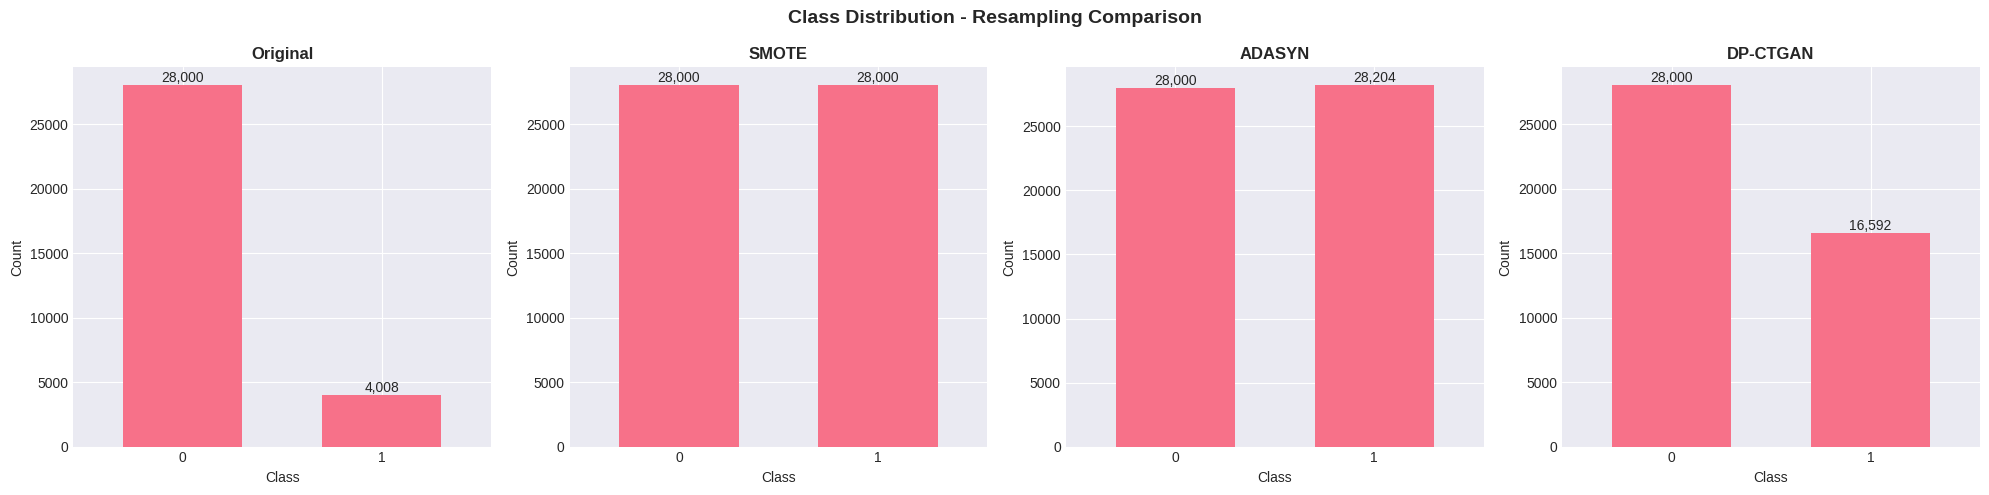


✅ Figure saved: /kaggle/working/outputs/figures/resampling_comparison_extended.png


In [6]:
# ================================================
# TRAIN-TEST SPLIT & CLASS IMBALANCE HANDLING 
# ================================================

import pickle
from imblearn.over_sampling import SMOTE, ADASYN

print("\n" + "="*100)
print("📦 TRAIN-TEST SPLIT & CLASS IMBALANCE HANDLING")
print("="*100)

# --- Split data (stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=y
)

print(f"\n📊 Data Split:")
print(f"   Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Original class distribution in training:")

# friendly class name map
label_map = {0: 'Normal (Class 0)', 1: 'Anomaly (Class 1)'}

train_dist = pd.Series(y_train).value_counts().sort_index()
for cls, count in train_dist.items():
    name = label_map.get(cls, f'Class {cls}')
    print(f"      {name}: {count:,} ({count/len(y_train)*100:.1f}%)")

# --- Feature Scaling ---
print(f"\n⚖️  Scaling features...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)
print(f"   ✅ Features scaled using StandardScaler")

# Save scaler
with open(config.MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"   ✅ Scaler saved: {config.MODELS_DIR / 'scaler.pkl'}")

print(f"\n🔄 Applying resampling strategies...")

# -------------------------
# SMOTE (define baseline smote outputs used by fallbacks)
# -------------------------
try:
    smote = SMOTE(random_state=config.RANDOM_STATE, k_neighbors=5)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
    print(f"   ✅ SMOTE: {np.bincount(y_train_smote)} (shape: {X_train_smote.shape})")
except Exception as e:
    print(f"   ⚠️  SMOTE failed: {str(e)[:120]}")
    # fallback to original scaled training set
    X_train_smote, y_train_smote = X_train_scaled.copy(), y_train.copy()

# -------------------------
# ADASYN
# -------------------------
try:
    adasyn = ADASYN(random_state=config.RANDOM_STATE)
    X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
    print(f"   ✅ ADASYN: {np.bincount(y_train_adasyn)} (shape: {X_train_adasyn.shape})")
except Exception as e:
    print(f"   ⚠️  ADASYN failed: {str(e)[:120]}")
    X_train_adasyn, y_train_adasyn = X_train_smote, y_train_smote

# -------------------------
# SMOTETomek
# -------------------------
try:
    smotetomek = SMOTETomek(random_state=config.RANDOM_STATE)
    X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)
    print(f"   ✅ SMOTETomek: {np.bincount(y_train_smotetomek)} (shape: {X_train_smotetomek.shape})")
except Exception as e:
    print(f"   ⚠️  SMOTETomek failed: {str(e)[:120]}")
    X_train_smotetomek, y_train_smotetomek = X_train_smote, y_train_smote

# -------------------------
# DP-CTGAN (generate synthetic minority rows and append)
# -------------------------
try:
    # Build a pandas DataFrame of training features + label (use UNscaled X_train so DP-CTGAN learns original distributions)
    train_df_for_synth = X_train.copy().reset_index(drop=True)
    train_df_for_synth['label'] = pd.Series(y_train).reset_index(drop=True).astype(int)

    print("\n   🔐 Training DP-CTGAN synthesizer (this may take a while)...")
    # Create the synthesizer (tune epsilon/epochs/sigma as required)
    dp_epsilon = 3.0      # privacy budget; larger -> higher utility, lower privacy
    dp_epochs = 200       # number of epochs to train; increase for better quality (costly)
    dp_batch = 256

    synth = Synthesizer.create(
        "dpctgan",
        epsilon=dp_epsilon,
        verbose=False,
        epochs=dp_epochs,
        batch_size=dp_batch
    )

    # Fit the synthesizer. preprocessor_eps reserves part of epsilon for preprocessing bounds inference.
    synth.fit(train_df_for_synth, preprocessor_eps=0.5)

    # Decide how many minority samples to generate (balance to majority class)
    train_counts = pd.Series(y_train).value_counts().sort_index()
    majority_count = int(train_counts.max())
    minority_label = int(train_counts.idxmin())
    minority_count = int(train_counts.min())
    needed = int(majority_count - minority_count)

    if needed <= 0:
        print("   ℹ️  Training data already balanced — no DP-CTGAN samples required.")
        X_train_dpctgan = X_train_scaled.copy().reset_index(drop=True)
        y_train_dpctgan = pd.Series(y_train).reset_index(drop=True).values
    else:
        print(f"   🔁 Generating {needed:,} synthetic rows conditioned on label = {minority_label} ...")
        cond = f"label = {minority_label}"
        synth_samples = synth.sample_conditional(n_rows=needed, condition=cond, max_tries=200)

        # Normalize to DataFrame
        if not isinstance(synth_samples, pd.DataFrame):
            synth_samples = pd.DataFrame(synth_samples, columns=train_df_for_synth.columns)

        synth_n = len(synth_samples)
        if synth_n == 0:
            print("   ⚠️  DP-CTGAN returned 0 synthetic samples (try increasing epochs or epsilon).")
            X_train_dpctgan = X_train_scaled.copy().reset_index(drop=True)
            y_train_dpctgan = pd.Series(y_train).reset_index(drop=True).values
        else:
            # Ensure column order and types match original feature set robustly
            synth_samples = synth_samples.reset_index(drop=True)
            synth_X = synth_samples.drop(columns=['label'], errors='ignore').reset_index(drop=True)
            synth_y = synth_samples['label'].astype(int).reset_index(drop=True)

            # Reindex to exactly the same columns as X_train (if missing columns, create them)
            synth_X = synth_X.reindex(columns=X_train.columns)

            # If any generated columns are missing (NaN), fill with median values from the real train_df
            medians = train_df_for_synth[X_train.columns].median()
            synth_X = synth_X.fillna(medians)

            # Scale synthetic samples using the existing scaler (scaler was fit earlier on X_train)
            synth_X_scaled = pd.DataFrame(
                scaler.transform(synth_X),
                columns=synth_X.columns,
                index=pd.RangeIndex(start=0, stop=len(synth_X))
            )

            # Append to the scaled training set (reset indices to concatenate cleanly)
            X_train_dpctgan = pd.concat(
                [X_train_scaled.reset_index(drop=True), synth_X_scaled.reset_index(drop=True)],
                axis=0,
                ignore_index=True
            )
            y_train_dpctgan = np.concatenate([pd.Series(y_train).reset_index(drop=True).values, synth_y.values], axis=0)

            print(f"   ✅ DP-CTGAN generated {synth_n:,} rows and appended to training set.")
            print(f"   New training shape: {X_train_dpctgan.shape}")

except ImportError as ie:
    print("   ⚠️  smartnoise-synth is not installed. Run: pip install smartnoise-synth")
    X_train_dpctgan, y_train_dpctgan = X_train_scaled.copy().reset_index(drop=True), pd.Series(y_train).reset_index(drop=True).values
except Exception as e:
    print(f"   ⚠️  DP-CTGAN failed: {str(e)[:200]}")
    X_train_dpctgan, y_train_dpctgan = X_train_scaled.copy().reset_index(drop=True), pd.Series(y_train).reset_index(drop=True).values

# -------------------------
# Choose which resampled set to use for training
# Example: use DP-CTGAN augmented set as primary for model training:
X_train_final, y_train_final = X_train_dpctgan, y_train_dpctgan

print(f"\n   Final training set for model fitting: {X_train_final.shape}, class counts: {np.bincount(y_train_final)}")

# ==============================
# Visualize class distributions (Updated: Includes DP-CTGAN)
# ==============================
print("\n📊 Visualizing class distributions...")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Class Distribution - Resampling Comparison', fontsize=14, fontweight='bold')

# 1) Original
train_dist = pd.Series(y_train).value_counts().sort_index()
train_dist.plot(kind='bar', ax=axes[0], width=0.6)
axes[0].set_title('Original', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(train_dist.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# 2) SMOTE
smote_dist = pd.Series(y_train_smote).value_counts().sort_index()
smote_dist.plot(kind='bar', ax=axes[1], width=0.6)
axes[1].set_title('SMOTE', fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(smote_dist.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

# 3) ADASYN
adasyn_dist = pd.Series(y_train_adasyn).value_counts().sort_index()
adasyn_dist.plot(kind='bar', ax=axes[2], width=0.6)
axes[2].set_title('ADASYN', fontweight='bold')
axes[2].set_xlabel('Class'); axes[2].set_ylabel('Count')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for i, v in enumerate(adasyn_dist.values):
    axes[2].text(i, v, f'{v:,}', ha='center', va='bottom')

# 4) DP-CTGAN
dpctgan_dist = pd.Series(y_train_dpctgan).value_counts().sort_index()
dpctgan_dist.plot(kind='bar', ax=axes[3], width=0.6)
axes[3].set_title('DP-CTGAN', fontweight='bold')
axes[3].set_xlabel('Class'); axes[3].set_ylabel('Count')
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=0)
for i, v in enumerate(dpctgan_dist.values):
    axes[3].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'resampling_comparison_extended.png',
            dpi=config.FIG_DPI, bbox_inches='tight')
plt.show()

print(f"\n✅ Figure saved: {config.FIGURES_DIR / 'resampling_comparison_extended.png'}")

# 7. Feature Selection: ANOVA → Genetic Algorithm → Mutual Information


🎯 FEATURE SELECTION (3-STAGE PIPELINE)

ℹ️  Using training source for feature selection: X_train_smote / y_train_smote
   Shape: (56000, 47)

📊 Step 1: ANOVA F-test Feature Selection
----------------------------------------------------------------------------------------------------

📈 Top 15 features by ANOVA F-score:


,Feature,F_Score,P_Value
0,e9_conn_outcome_Success,27448.485678,0.0
1,e2c_total_bytes_log,22175.047811,0.0
2,e2c_total_bytes_sqrt,20886.737344,0.0
3,e2_server_record_len,17046.272529,0.0
4,e2c_total_bytes,16725.198987,0.0
5,e9_conn_outcome_Failure,12034.294184,0.0
6,e1_alg_suite_mlkem1024,11946.582391,0.0
7,e1_alg_suite_mlkem768,10902.089355,0.0
8,e1_alg_suite_x25519,7572.710498,0.0
9,throughput_bps entropy_combined,6813.079628,0.0



✅ Selected 23 features from ANOVA (top 50%)

🧬 Step 2: Genetic Algorithm Feature Selection
----------------------------------------------------------------------------------------------------

🔄 Running Genetic Algorithm...

----------------------------------------------------------------------------------------------------
🧬 Step 2: Genetic Algorithm - Full Results
----------------------------------------------------------------------------------------------------

📋 GA generation statistics (summary):


,gen,avg,max
0,0,0.8944,0.9047
1,1,0.9020,0.9048
2,2,0.9033,0.9048
3,3,0.9038,0.9050
4,4,0.9046,0.9050
5,5,0.9047,0.9050
6,6,0.9042,0.9050
7,7,0.9045,0.9050
8,8,0.9044,0.9050
9,9,0.9047,0.9050


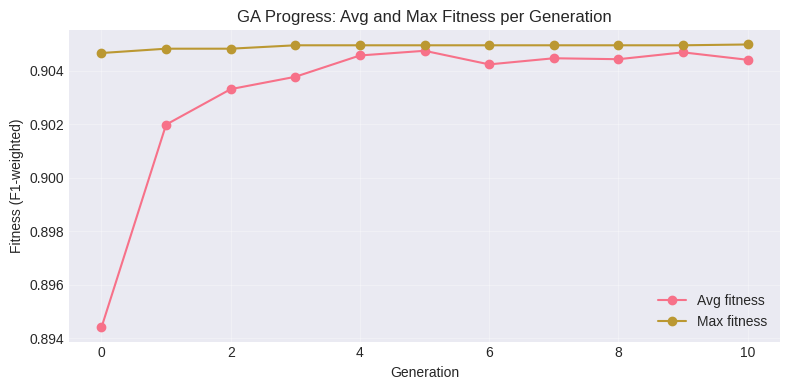


   Figure saved: /kaggle/working/outputs/figures/GA Progress.png

✅ GA selected 14 features
   Best fitness (F1-weighted): 0.9050

📈 Step 3: Mutual Information Ranking
----------------------------------------------------------------------------------------------------

📊 Mutual Information Scores (top):


,Feature,MI_Score
0,e2c_total_bytes_log,0.553709
1,e2c_total_bytes_sqrt,0.553133
2,e6b_flow_duration_ms,0.438159
3,e6b_flow_duration_ms_sqrt,0.437086
4,throughput_bps,0.309164
5,e2_server_record_len,0.243524
6,e9_conn_outcome_Success,0.217615
7,e1_alg_suite_mlkem768,0.088380
8,e9_conn_outcome_Incomplete,0.074116
9,e1b_ciphersuite_54,0.038995



✅ Final 14 features selected:
   1. e2c_total_bytes_log
   2. e2c_total_bytes_sqrt
   3. e6b_flow_duration_ms
   4. e6b_flow_duration_ms_sqrt
   5. throughput_bps
   6. e2_server_record_len
   7. e9_conn_outcome_Success
   8. e1_alg_suite_mlkem768
   9. e9_conn_outcome_Incomplete
   10. e1b_ciphersuite_54
   11. e3_cert_parsed
   12. e1b_ciphersuite_60
   13. e8_proto_context_TLSv1.3
   14. e3_sig_alg_nan


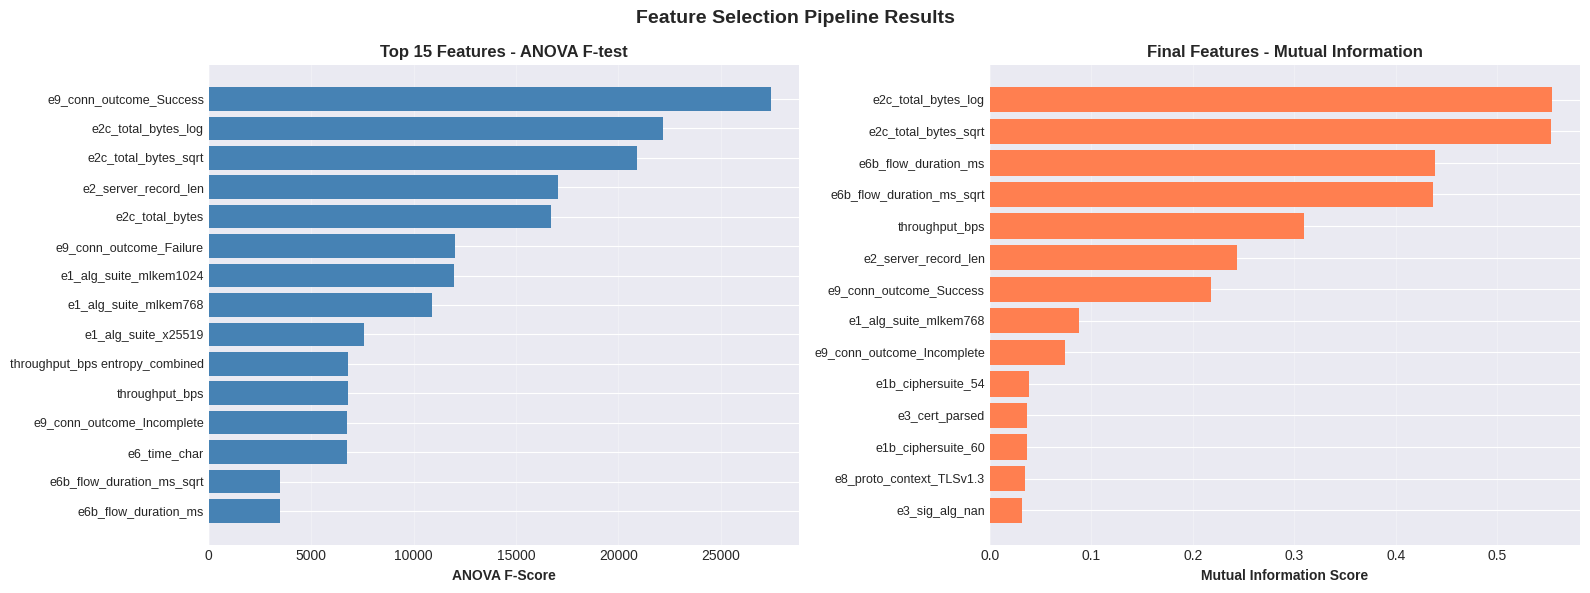


✅ Feature Selection Complete
   Original features: 47
   After ANOVA: 23
   After GA: 14
   Final features: 14
   Reduction: 70.2%

   Figure saved: /kaggle/working/outputs/figures/feature_selection.png


In [7]:
# ============================================================================
# FEATURE SELECTION: ANOVA → GENETIC ALGORITHM → MUTUAL INFORMATION
# ============================================================================

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import cross_val_score

print("\n" + "="*50)
print("🎯 FEATURE SELECTION (3-STAGE PIPELINE)")
print("="*50)

if 'X_train_smote' in globals() and 'y_train_smote' in globals():
    base_X_train = X_train_smote.copy().reset_index(drop=True)
    base_y_train = pd.Series(y_train_smote).reset_index(drop=True).values
    source_desc = "X_train_smote / y_train_smote"
elif 'X_train_final' in globals() and 'y_train_final' in globals():
    base_X_train = pd.DataFrame(X_train_final).copy().reset_index(drop=True)
    base_y_train = pd.Series(y_train_final).reset_index(drop=True).values
    # ensure columns names if X_train_final is numpy array
    if base_X_train.shape[1] == X.columns.shape[0]:
        base_X_train.columns = X.columns
    source_desc = "X_train_final / y_train_final (fallback)"
else:
    base_X_train = X_train.copy().reset_index(drop=True)
    base_y_train = pd.Series(y_train).reset_index(drop=True).values
    source_desc = "X_train (raw fallback)"

print(f"\nℹ️  Using training source for feature selection: {source_desc}")
print(f"   Shape: {base_X_train.shape}")

# Keep X_test_scaled as provided; ensure columns align
X_test_scaled = X_test_scaled.reset_index(drop=True)

# ==================== Step 1: ANOVA Feature Selection ====================
print("\n📊 Step 1: ANOVA F-test Feature Selection")
print("-"*100)

# Perform ANOVA F-test (k='all' to get scores for ranking)
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(base_X_train, base_y_train)

# Get F-scores and p-values
anova_scores = pd.DataFrame({
    'Feature': base_X_train.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
})

anova_scores = anova_scores.sort_values('F_Score', ascending=False).reset_index(drop=True)

print(f"\n📈 Top 15 features by ANOVA F-score:")
display(anova_scores.head(15))

# Select top k features (50% or at least 10)
k_anova = max(10, int(len(base_X_train.columns) * 0.5))
top_anova_features = anova_scores.head(k_anova)['Feature'].tolist()

print(f"\n✅ Selected {len(top_anova_features)} features from ANOVA (top 50%)")

# Create filtered dataset for downstream GA
X_train_anova = base_X_train[top_anova_features].reset_index(drop=True)
X_test_anova = X_test_scaled[top_anova_features].reset_index(drop=True)

# ==================== Step 2: Genetic Algorithm Feature Selection ====================
print("\n🧬 Step 2: Genetic Algorithm Feature Selection")
print("-"*100)

# Safe creation of DEAP creator types (avoid re-creation error)
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator: 0 or 1
toolbox.register("attr_bool", lambda: np.random.randint(0, 2))
# Individual: list of 0/1 of length = number of ANOVA-selected features
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=len(top_anova_features))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness evaluation function - returns (mean_score,)
def evaluate_features(individual):
    selected_indices = [i for i, bit in enumerate(individual) if int(bit) == 1]
    if len(selected_indices) == 0:
        return (0.0,)  # no features selected -> worst fitness

    # Select corresponding columns by index to avoid label mismatch
    X_selected = X_train_anova.iloc[:, selected_indices]

    clf = RandomForestClassifier(
        n_estimators=50,
        max_depth=5,
        random_state=getattr(config, 'RANDOM_STATE', 42),
        n_jobs=getattr(config, 'N_JOBS', 1)
    )

    # 3-fold CV (weighted F1)
    try:
        cv_scores = cross_val_score(clf, X_selected, base_y_train, cv=3, scoring='f1_weighted', n_jobs=getattr(config, 'N_JOBS', 1))
        return (np.mean(cv_scores),)
    except Exception:
        # If CV fails (e.g., constant labels in folds), return zero fitness
        return (0.0,)

toolbox.register("evaluate", evaluate_features)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# GA hyperparameters
POP_SIZE = 20
NGEN = 10
CX_PB = 0.7
MUT_PB = 0.2

print(f"\n🔄 Running Genetic Algorithm...")
# initialize population
population = toolbox.population(n=POP_SIZE)

# statistics
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

# run GA (quiet)
population, logbook = algorithms.eaSimple(
    population, toolbox,
    cxpb=CX_PB, mutpb=MUT_PB,
    ngen=NGEN, stats=stats, verbose=False
)

# Best individual
best_individual = tools.selBest(population, k=1)[0]
ga_selected_indices = [i for i, bit in enumerate(best_individual) if int(bit) == 1]
ga_selected_features = [top_anova_features[i] for i in ga_selected_indices]

best_fitness = best_individual.fitness.values[0] if len(best_individual.fitness.values) > 0 else 0.0

print("\n" + "-"*100)
print("🧬 Step 2: Genetic Algorithm - Full Results")
print("-"*100)

# 1) Turn logbook into a DataFrame (if available)
if 'logbook' in globals() and len(logbook) > 0:
    try:
        log_df = pd.DataFrame(list(logbook))
        # Keep only typical columns if present
        cols_keep = [c for c in ['gen', 'avg', 'max', 'min', 'std'] if c in log_df.columns]
        print("\n📋 GA generation statistics (summary):")
        display(log_df[cols_keep].round(4))
    except Exception as e:
        print("⚠️  Could not render logbook table:", str(e))
else:
    print("ℹ️  No logbook found (no GA history available).")

    
# 2) Plot generation progression (avg & max fitness)
if 'logbook' in globals() and len(logbook) > 0:
    plt.figure(figsize=(8,4))
    if 'avg' in log_df.columns:
        plt.plot(log_df['gen'], log_df['avg'], marker='o', label='Avg fitness')
    if 'max' in log_df.columns:
        plt.plot(log_df['gen'], log_df['max'], marker='o', label='Max fitness')
    plt.xlabel('Generation')
    plt.ylabel('Fitness (F1-weighted)')
    plt.title('GA Progress: Avg and Max Fitness per Generation')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'GA Progress.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n   Figure saved: {config.FIGURES_DIR / 'GA Progress.png'}")
else:
    print("ℹ️  Skipping GA progression plot (logbook missing).")

print(f"\n✅ GA selected {len(ga_selected_features)} features")
print(f"   Best fitness (F1-weighted): {best_fitness:.4f}")

# Create GA-filtered datasets
X_train_ga = X_train_anova[ga_selected_features].reset_index(drop=True)
X_test_ga = X_test_anova[ga_selected_features].reset_index(drop=True)

# ==================== Step 3: Mutual Information Ranking ====================
print("\n📈 Step 3: Mutual Information Ranking")
print("-"*100)

# Calculate mutual information on GA-selected features
mi_scores = mutual_info_classif(X_train_ga, base_y_train, random_state=getattr(config, 'RANDOM_STATE', 42))
mi_df = pd.DataFrame({
    'Feature': ga_selected_features,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print(f"\n📊 Mutual Information Scores (top):")
display(mi_df.head(15))

# Select top features based on MI
top_k_final = min(15, len(ga_selected_features))
final_selected_features = mi_df.head(top_k_final)['Feature'].tolist()

print(f"\n✅ Final {len(final_selected_features)} features selected:")
for i, feat in enumerate(final_selected_features, 1):
    print(f"   {i}. {feat}")

# Final datasets for modeling
X_train_selected = X_train_ga[final_selected_features].reset_index(drop=True)
X_test_selected = X_test_ga[final_selected_features].reset_index(drop=True)

# Replace previous X_train_final/X_test_final variable names for backward compatibility
X_train_final = X_train_selected.copy()
X_test_final = X_test_selected.copy()
y_train_final = base_y_train.copy()

# ====================
# Visualization
# ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANOVA scores (top 15)
anova_top15 = anova_scores.head(15).iloc[::-1]
axes[0].barh(range(len(anova_top15)), anova_top15['F_Score'], color='steelblue')
axes[0].set_yticks(range(len(anova_top15)))
axes[0].set_yticklabels(anova_top15['Feature'], fontsize=9)
axes[0].set_xlabel('ANOVA F-Score', fontweight='bold')
axes[0].set_title('Top 15 Features - ANOVA F-test', fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# MI scores (final features) - reversed for horizontal bar
mi_df_plot = mi_df.iloc[::-1]
axes[1].barh(range(len(mi_df_plot)), mi_df_plot['MI_Score'], color='coral')
axes[1].set_yticks(range(len(mi_df_plot)))
axes[1].set_yticklabels(mi_df_plot['Feature'], fontsize=9)
axes[1].set_xlabel('Mutual Information Score', fontweight='bold')
axes[1].set_title('Final Features - Mutual Information', fontweight='bold', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Selection Pipeline Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'feature_selection.png',
            dpi=getattr(config, 'FIG_DPI', 150), bbox_inches='tight')
plt.show()

# Summary
print(f"\n{'='*100}")
print(f"✅ Feature Selection Complete")
print(f"{'='*100}")
print(f"   Original features: {X.shape[1]}")
print(f"   After ANOVA: {len(top_anova_features)}")
print(f"   After GA: {len(ga_selected_features)}")
print(f"   Final features: {len(final_selected_features)}")
print(f"   Reduction: {(1 - len(final_selected_features)/X.shape[1])*100:.1f}%")
print(f"\n   Figure saved: {config.FIGURES_DIR / 'feature_selection.png'}")

# 8. Multi-Stage Detection System: L1 Rules → L2 Thresholds → L3 ML Ensemble

In [8]:
# ==================== L1: Deterministic Rule-Based Detection ====================
print("🔍 Level 1: Deterministic Rule-Based Detection\n")

def apply_l1_rules(X):
    """Apply deterministic rules for obvious anomalies"""
    anomalies = np.zeros(len(X), dtype=bool)
    
    # Get column names that exist in the dataset
    available_cols = X.columns.tolist()
    
    # Rule 1: Extremely high packet count (protocol violation)
    packet_cols = [col for col in available_cols if 'packet' in col.lower() and 'count' in col.lower()]
    for col in packet_cols:
        # Use percentile-based threshold instead of hardcoded value
        threshold = X[col].quantile(0.99)
        anomalies |= (X[col] > threshold * 2)
    
    # Rule 2: Negative or zero duration (impossible)
    duration_cols = [col for col in available_cols if 'duration' in col.lower() or 'time' in col.lower()]
    for col in duration_cols:
        anomalies |= (X[col] <= 0)
    
    # Rule 3: Entropy outside valid range
    entropy_cols = [col for col in available_cols if 'entropy' in col.lower()]
    for col in entropy_cols:
        anomalies |= (X[col] < 0) | (X[col] > 8)
    
    return anomalies.astype(int)

# Apply L1 rules
l1_predictions = apply_l1_rules(X_test_final)
l1_detected = l1_predictions.sum()

print(f"L1 detected {l1_detected} anomalies ({100*l1_detected/len(l1_predictions):.2f}%)")

# ==================== L2: Threshold-Based Detection ====================
print("\n📏 Level 2: Threshold-Based Detection\n")

def apply_l2_thresholds(X, thresholds):
    """Apply statistical threshold rules with IQR method"""
    anomalies = np.zeros(len(X), dtype=bool)
    
    for feature, (lower, upper) in thresholds.items():
        if feature in X.columns:
            anomalies |= (X[feature] < lower) | (X[feature] > upper)
    
    return anomalies.astype(int)

# Calculate thresholds using IQR method (more robust than 3-sigma)
thresholds = {}
for col in X_train_final.columns:
    Q1 = X_train_final[col].quantile(0.25)
    Q3 = X_train_final[col].quantile(0.75)
    IQR = Q3 - Q1
    thresholds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Apply L2 thresholds to samples not caught by L1
l1_mask = l1_predictions == 0
l2_predictions = np.zeros(len(X_test_final), dtype=int)
l2_predictions[l1_mask] = apply_l2_thresholds(X_test_final[l1_mask], thresholds)

l2_detected = l2_predictions.sum()
print(f"L2 detected {l2_detected} additional anomalies ({100*l2_detected/len(l2_predictions):.2f}%)")

# ==================== L3: Machine Learning Ensemble (IMPROVED) ====================
print("\n🤖 Level 3: Machine Learning Ensemble (Optimized)\n")

# Enhanced classifiers with better hyperparameters
classifiers = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=15, 
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_SEED, 
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, 
        max_depth=8, 
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train_smote == 0).sum() / (y_train_smote == 1).sum(),
        random_state=RANDOM_SEED, 
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, 
        max_depth=8, 
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_SEED, 
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=8,
        learning_rate=0.05,
        auto_class_weights='Balanced',
        random_state=RANDOM_SEED,
        verbose=False
    ),
    'Extra Trees': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        criterion='entropy',
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
}

# Train and evaluate each classifier with cross-validation
from sklearn.model_selection import cross_validate

l3_results = {}
trained_models = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    
    # Cross-validation on training set
    cv_results = cross_validate(
        clf, X_train_final, y_train_smote, 
        cv=5, 
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        return_train_score=False,
        n_jobs=-1
    )
    
    print(f"  CV F1-Score: {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")
    
    # Train on full training set
    start_time = time.time()
    clf.fit(X_train_final, y_train_smote)
    train_time = time.time() - start_time
    
    # Predict on test set
    start_time = time.time()
    y_pred = clf.predict(X_test_final)
    predict_time = time.time() - start_time
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    l3_results[name] = {
        'CV_F1_Mean': cv_results['test_f1_weighted'].mean(),
        'CV_F1_Std': cv_results['test_f1_weighted'].std(),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'Train_Time': train_time,
        'Predict_Time': predict_time
    }
    
    trained_models[name] = clf
    
    print(f"  Test F1-Score: {f1:.4f}")

# Display results
l3_results_df = pd.DataFrame(l3_results).T
print("\n📊 L3 Individual Model Performance:")
display(l3_results_df.sort_values('F1_Score', ascending=False))

# Create Weighted Voting Ensemble (using top 3 models)
print("\n🗳️ Creating Weighted Voting Ensemble...")
top_3_models = l3_results_df.nlargest(3, 'F1_Score').index.tolist()
weights = l3_results_df.loc[top_3_models, 'F1_Score'].values

voting_clf = VotingClassifier(
    estimators=[(name, trained_models[name]) for name in top_3_models],
    voting='soft',
    weights=weights
)
voting_clf.fit(X_train_final, y_train_smote)
y_pred_voting = voting_clf.predict(X_test_final)

# Evaluate ensemble
ensemble_acc = accuracy_score(y_test, y_pred_voting)
ensemble_prec = precision_score(y_test, y_pred_voting, average='weighted', zero_division=0)
ensemble_rec = recall_score(y_test, y_pred_voting, average='weighted', zero_division=0)
ensemble_f1 = f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)

print(f"\nVoting Ensemble Performance:")
print(f"  Accuracy: {ensemble_acc:.4f}")
print(f"  Precision: {ensemble_prec:.4f}")
print(f"  Recall: {ensemble_rec:.4f}")
print(f"  F1-Score: {ensemble_f1:.4f}")

# Store best model
best_model_name = l3_results_df['F1_Score'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_final)

print(f"\n🏆 Best Individual Model: {best_model_name} (F1: {l3_results_df.loc[best_model_name, 'F1_Score']:.4f})")

# Combined multi-stage predictions
combined_predictions = np.maximum(l1_predictions, np.maximum(l2_predictions, y_pred_voting))

print("\n✅ Multi-stage detection complete!")
print(f"Total anomalies detected: {combined_predictions.sum()} / {len(combined_predictions)}")

# Detailed breakdown
print("\n📊 Detection Stage Breakdown:")
print(f"  L1 (Rules): {l1_detected} anomalies")
print(f"  L2 (Thresholds): {l2_detected} anomalies")
print(f"  L3 (ML Ensemble): {y_pred_voting.sum()} anomalies")
print(f"  Combined Total: {combined_predictions.sum()} anomalies")

🔍 Level 1: Deterministic Rule-Based Detection

L1 detected 7808 anomalies (97.58%)

📏 Level 2: Threshold-Based Detection

L2 detected 194 additional anomalies (2.42%)

🤖 Level 3: Machine Learning Ensemble (Optimized)

Training Random Forest...
  CV F1-Score: 0.9155 (+/- 0.0033)
  Test F1-Score: 0.9145
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:58:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:58:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:58:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:58:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:58:32] WARNING: /w

  CV F1-Score: 0.9134 (+/- 0.0017)
  Test F1-Score: 0.9083
Training LightGBM...
  CV F1-Score: 0.9126 (+/- 0.0019)
  Test F1-Score: 0.9067
Training CatBoost...
  CV F1-Score: 0.9130 (+/- 0.0030)
  Test F1-Score: 0.9059
Training Extra Trees...
  CV F1-Score: 0.9155 (+/- 0.0034)
  Test F1-Score: 0.9104

📊 L3 Individual Model Performance:


,CV_F1_Mean,CV_F1_Std,Accuracy,Precision,Recall,F1_Score,Train_Time,Predict_Time
Random Forest,0.915481,0.003302,0.906148,0.934658,0.906148,0.914474,2.400678,0.067450
Extra Trees,0.915508,0.003367,0.901025,0.933458,0.901025,0.910382,2.839161,0.076896
XGBoost,0.913419,0.001715,0.898275,0.933219,0.898275,0.908256,0.484211,0.021701
LightGBM,0.912570,0.001899,0.896276,0.932903,0.896276,0.906685,0.749557,0.039024
CatBoost,0.913010,0.002984,0.895276,0.932688,0.895276,0.905890,2.476311,0.006340



🗳️ Creating Weighted Voting Ensemble...

Voting Ensemble Performance:
  Accuracy: 0.8999
  Precision: 0.9337
  Recall: 0.8999
  F1-Score: 0.9096

🏆 Best Individual Model: Random Forest (F1: 0.9145)

✅ Multi-stage detection complete!
Total anomalies detected: 8002 / 8002

📊 Detection Stage Breakdown:
  L1 (Rules): 7808 anomalies
  L2 (Thresholds): 194 anomalies
  L3 (ML Ensemble): 1637 anomalies
  Combined Total: 8002 anomalies


# Multi-stage Detection Pipeline (Optuna + Stacking + Threshold Tuning)

In [ ]:
# ==============================
# MULTI-STAGE DETECTION PIPELINE (OPTUNA + STACKING + THRESHOLD TUNING)
# ==============================

import warnings
warnings.filterwarnings("ignore")

# ML libs
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import VotingClassifier

# Optional: Optuna for tuning CatBoost (fast wins)
try:
    import optuna
    HAS_OPTUNA = True
except Exception:
    HAS_OPTUNA = False

# friendly label names
label_map = {0: 'Normal (Class 0)', 1: 'Anomaly (Class 1)'}
RND = getattr(config, 'RANDOM_SEED', 42)

# --------------------
# Helpers & fallbacks (ensure DataFrames)
# --------------------
def ensure_df(X, columns_ref=None):
    if isinstance(X, pd.DataFrame):
        return X.reset_index(drop=True)
    else:
        cols = columns_ref if columns_ref is not None else None
        return pd.DataFrame(X, columns=cols).reset_index(drop=True)

# pick training set (prefer y_train_smote)
if 'X_train_final' in globals():
    X_train_full = ensure_df(X_train_final, columns_ref=(X.columns if 'X' in globals() else None))
else:
    X_train_full = ensure_df(X_train, columns_ref=(X.columns if 'X' in globals() else None))

if 'y_train_smote' in globals():
    y_train_full = np.array(y_train_smote)
elif 'y_train_final' in globals():
    y_train_full = np.array(y_train_final)
else:
    y_train_full = np.array(y_train)

X_test_df = ensure_df(X_test_final, columns_ref=X_train_full.columns)
y_test_arr = np.array(y_test)

print(f"Using training shape: {X_train_full.shape}, test shape: {X_test_df.shape}")

# --------------------
# L1 and L2 functions (re-declared to be self-contained)
# --------------------
def apply_l1_rules(X_target, X_ref=None):
    anomalies = np.zeros(len(X_target), dtype=bool)
    available_cols = X_target.columns.tolist()
    ref = X_ref if X_ref is not None else X_target

    # Rule 1: high packet count
    packet_cols = [col for col in available_cols if 'packet' in col.lower() and 'count' in col.lower()]
    for col in packet_cols:
        try:
            threshold_ref = ref[col].quantile(0.99)
            anomalies |= (X_target[col] > threshold_ref * 2)
        except Exception:
            continue

    # Rule 2: non-positive duration/time
    duration_cols = [col for col in available_cols if 'duration' in col.lower() or 'time' in col.lower()]
    for col in duration_cols:
        try:
            anomalies |= (X_target[col] <= 0)
        except Exception:
            continue

    # Rule 3: entropy outside plausible bounds
    entropy_cols = [col for col in available_cols if 'entropy' in col.lower()]
    for col in entropy_cols:
        try:
            anomalies |= (X_target[col] < 0) | (X_target[col] > 8)
        except Exception:
            continue

    return anomalies.astype(int)

def compute_iqr_thresholds(X_ref, multiplier=1.5):
    thresholds = {}
    for col in X_ref.columns:
        Q1 = X_ref[col].quantile(0.25)
        Q3 = X_ref[col].quantile(0.75)
        IQR = Q3 - Q1
        thresholds[col] = (Q1 - multiplier * IQR, Q3 + multiplier * IQR)
    return thresholds

def apply_l2_thresholds(X_target, thresholds):
    anomalies = np.zeros(len(X_target), dtype=bool)
    for feature, (lower, upper) in thresholds.items():
        if feature in X_target.columns:
            anomalies |= (X_target[feature] < lower) | (X_target[feature] > upper)
    return anomalies.astype(int)

# compute L1/L2 on test (L1 uses training reference)
l1_test = apply_l1_rules(X_test_df, X_ref=X_train_full)
thresholds = compute_iqr_thresholds(X_train_full, multiplier=1.5)
# apply to all test rows but we'll later mask away ones already flagged by L1 if needed
l2_test_full = apply_l2_thresholds(X_test_df, thresholds)

# --------------------
# Create validation holdout from training for threshold tuning & model selection
# --------------------
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RND
)
print(f"Holdout validation created: train {X_train_sub.shape}, val {X_val_sub.shape}")

# --------------------
# Optuna: tune CatBoost quickly (fallback to default if not installed)
# --------------------
best_cat_params = None
if HAS_OPTUNA:
    def objective_cat(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 200, 1000),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.2),
            'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 2.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'verbose': False,
            'random_seed': RND,
            'auto_class_weights': 'Balanced'
        }
        clf = CatBoostClassifier(**params)
        # quick CV using small folds on sub-train for speed
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RND)
        scores = []
        for tr_idx, val_idx in skf.split(X_train_sub, y_train_sub):
            clf.fit(X_train_sub.iloc[tr_idx], y_train_sub[tr_idx])
            preds = clf.predict(X_train_sub.iloc[val_idx])
            scores.append(f1_score(y_train_sub[val_idx], preds, average='weighted'))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize', study_name='catboost_quick')
    study.optimize(objective_cat, n_trials=30, n_jobs=1, show_progress_bar=False)
    best_cat_params = study.best_trial.params
    print("Optuna found CatBoost params:", best_cat_params)
else:
    print("Optuna not available — using default CatBoost hyperparameters.")

# --------------------
# Base models: tuned CatBoost (if available), XGBoost, LightGBM
# --------------------
cat_params = best_cat_params.copy() if best_cat_params is not None else {}
cat_params.update({'verbose': False, 'random_seed': RND, 'auto_class_weights':'Balanced'})
cat_clf = CatBoostClassifier(**cat_params)

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='logloss', random_state=RND
)
lgb_clf = lgb.LGBMClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, class_weight='balanced', random_state=RND
)

base_models = [
    ('cat', cat_clf),
    ('xgb', xgb_clf),
    ('lgb', lgb_clf)
]

# --------------------
# Generate OOF predictions for stacking (prob of positive class)
# --------------------
print("\nGenerating OOF predictions for stacking (this may take a few minutes)...")
n_models = len(base_models)
oof_train = np.zeros((X_train_full.shape[0], n_models))
oof_test = np.zeros((X_test_df.shape[0], n_models))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
for i, (name, model) in enumerate(base_models):
    print(f"  OOF for {name} ...")
    # cross_val_predict gives probabilities on train (oof) using CV
    try:
        oof = cross_val_predict(model, X_train_full, y_train_full, cv=skf, method='predict_proba', n_jobs=-1)[:,1]
    except Exception:
        # fallback: manual OOF to avoid cross_val_predict issues (slower)
        oof = np.zeros(X_train_full.shape[0])
        for tr_idx, val_idx in skf.split(X_train_full, y_train_full):
            model.fit(X_train_full.iloc[tr_idx], y_train_full[tr_idx])
            oof[val_idx] = model.predict_proba(X_train_full.iloc[val_idx])[:,1]
    # fit model on full training for test predictions
    model.fit(X_train_full, y_train_full)
    test_probs = model.predict_proba(X_test_df)[:,1]
    oof_train[:, i] = oof
    oof_test[:, i] = test_probs

# Add L1/L2 indicators as meta features (compute on train_full and test)
l1_train_full = apply_l1_rules(X_train_full, X_ref=X_train_full)
l2_train_full = apply_l2_thresholds(X_train_full, thresholds)
l1_test_vec = l1_test  # computed earlier
l2_test_vec = l2_test_full

# Append rule flags to meta features
meta_train = np.hstack([
    oof_train,
    l1_train_full.to_numpy().reshape(-1, 1),
    l2_train_full.to_numpy().reshape(-1, 1)
])

meta_test = np.hstack([
    oof_test,
    l1_test_vec.to_numpy().reshape(-1, 1),
    l2_test_vec.to_numpy().reshape(-1, 1)
])

print("Meta features shape:", meta_train.shape, meta_test.shape)

# --------------------
# Build meta-learner (Logistic Regression) - train on meta_train using a validation split
# --------------------
# Split meta_train for threshold tuning (MV = meta validation)
meta_X_train, meta_X_val, meta_y_train, meta_y_val = train_test_split(
    meta_train, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RND
)

meta_clf = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RND)
meta_clf.fit(meta_X_train, meta_y_train)

# Calibrate meta probabilities (improves thresholding)
calibrator = CalibratedClassifierCV(meta_clf, cv=3, method='sigmoid')
calibrator.fit(meta_X_train, meta_y_train)   # fit on meta training part
meta_val_probs = calibrator.predict_proba(meta_X_val)[:,1]
meta_test_probs = calibrator.predict_proba(meta_test)[:,1]

# Find best threshold on meta validation (use F1-weighted or class-specific metric)
best_thr = 0.5
best_f1 = -1
for thr in np.linspace(0.1, 0.9, 81):
    preds = (meta_val_probs >= thr).astype(int)
    f1_thr = f1_score(meta_y_val, preds, average='weighted')
    if f1_thr > best_f1:
        best_f1 = f1_thr
        best_thr = thr
print(f"Chosen meta threshold (from validation): {best_thr:.3f} (val F1={best_f1:.4f})")

# Meta predictions on test
meta_test_preds = (meta_test_probs >= best_thr).astype(int)

# --------------------
# Conservative combination: meta OR (L1 AND L2)
# --------------------
final_preds = ( (meta_test_preds == 1) | ((l1_test_vec == 1) & (l2_test_vec == 1)) ).astype(int)

# Evaluate results
print("\n=== Evaluation: Final Combined (meta OR (L1 AND L2)) ===")
print("Classification report (test):")
print(classification_report(y_test_arr, final_preds, target_names=[label_map[0], label_map[1]], zero_division=0))
print(f"Accuracy: {accuracy_score(y_test_arr, final_preds):.4f}")
print(f"Precision (weighted): {precision_score(y_test_arr, final_preds, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted): {recall_score(y_test_arr, final_preds, average='weighted', zero_division=0):.4f}")
print(f"F1 (weighted): {f1_score(y_test_arr, final_preds, average='weighted', zero_division=0):.4f}")

# Also show L3-only (meta alone) for comparison
print("\n=== L3 (meta only) performance ===")
meta_only = meta_test_preds
print(classification_report(y_test_arr, meta_only, target_names=[label_map[0], label_map[1]], zero_division=0))
print(f"Meta-only F1 (weighted): {f1_score(y_test_arr, meta_only, average='weighted', zero_division=0):.4f}")

# Print counts breakdown
def print_counts(name, preds):
    counts = np.bincount(preds, minlength=2)
    n = len(preds)
    print(f"\n{name}:")
    for cls_idx, cnt in enumerate(counts):
        print(f"  {label_map.get(cls_idx)} : {cnt:,} ({100*cnt/n:.2f}%)")

print_counts("L1 (test)", l1_test_vec)
print_counts("L2 (test)", l2_test_vec)
print_counts("Meta-only (test)", meta_only)
print_counts("Final combined (test)", final_preds)

# --------------------
# Optional: Save final meta model and base models
# --------------------
import joblib
joblib.dump({'meta_clf': calibrator, 'base_models': {name:model for name,model in base_models}},
            config.MODELS_DIR / 'final_ensemble.joblib')
print(f"\nSaved ensemble to: {config.MODELS_DIR / 'final_ensemble.joblib' }")

# 9. Model Evaluation & Performance Metrics

🏆 Best Model: Random Forest

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.91      0.94      7000
     Anomaly       0.58      0.91      0.71      1002

    accuracy                           0.91      8002
   macro avg       0.78      0.91      0.83      8002
weighted avg       0.93      0.91      0.91      8002



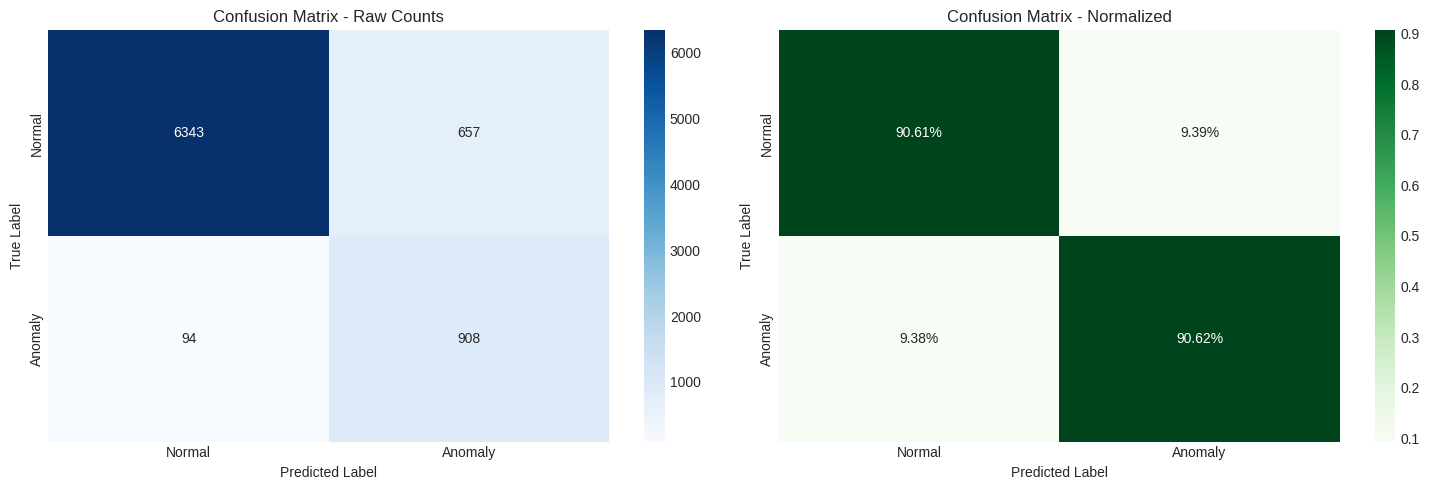

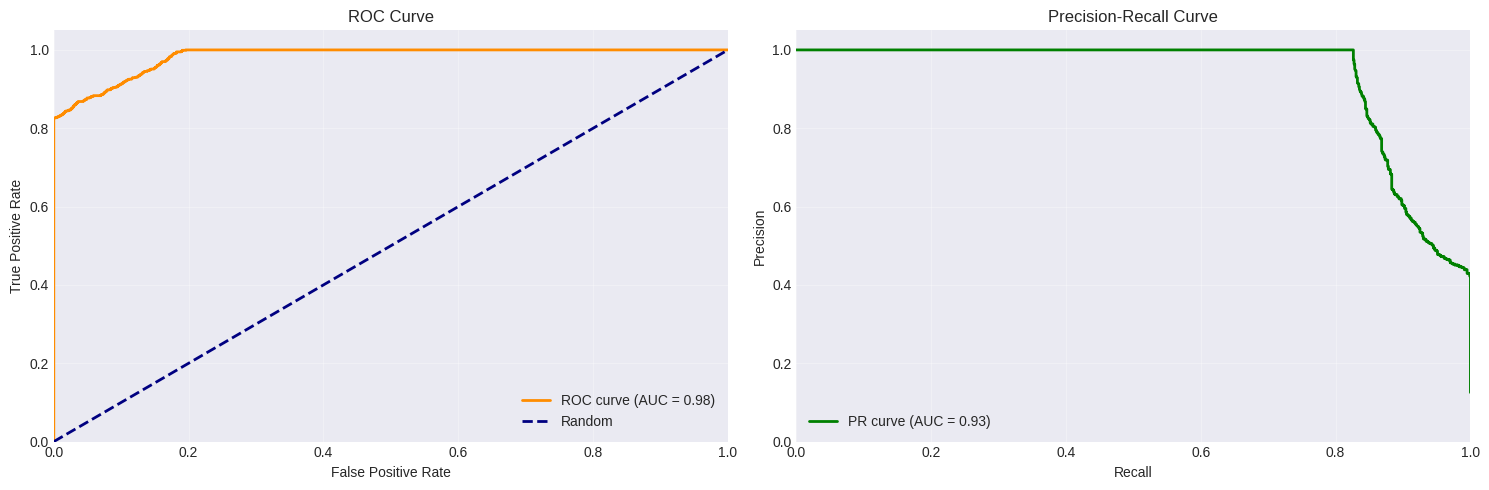


📊 Additional Metrics:
Matthews Correlation Coefficient: 0.6778
ROC-AUC Score: 0.9830


In [10]:
# Get the best performing model from L3
best_model_name = l3_results_df['F1_Score'].idxmax()
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name}\n")

# Predictions
y_pred_best = best_model.predict(X_test_final)
y_pred_proba = best_model.predict_proba(X_test_final)[:, 1] if hasattr(best_model, 'predict_proba') else None

# ==================== Classification Report ====================
print("📋 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Anomaly']))

# ==================== Confusion Matrix ====================
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix - Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Confusion Matrix - Normalized')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ==================== ROC and PR Curves ====================
if y_pred_proba is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    axes[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(loc="lower left")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== Additional Metrics ====================
print("\n📊 Additional Metrics:")
print(f"Matthews Correlation Coefficient: {matthews_corrcoef(y_test, y_pred_best):.4f}")
if y_pred_proba is not None:
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# 10. Explainability: SHAP & LIME Analysis

In [ ]:
# ==================== SHAP Analysis ====================
print("🔬 SHAP (SHapley Additive exPlanations) Analysis\n")

# Determine which model to use for SHAP
shap_compatible_models = ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'Gradient Boosting']

# Find the best tree-based model for SHAP
shap_model = None
shap_model_name = None

# Check if best_model is a VotingClassifier or StackingClassifier
if hasattr(best_model, 'named_estimators_'):
    # It's a VotingClassifier or StackingClassifier with named_estimators_
    print("Detected ensemble model (Voting/Stacking), extracting base estimator...")
    for name in shap_compatible_models:
        if name in best_model.named_estimators_:
            shap_model = best_model.named_estimators_[name]
            shap_model_name = name
            print(f"   Using {name} from ensemble")
            break
    
    # If not found in compatible list, use first available
    if shap_model is None:
        first_name = list(best_model.named_estimators_.keys())[0]
        shap_model = best_model.named_estimators_[first_name]
        shap_model_name = first_name
        print(f"   Using {first_name} from ensemble")

elif hasattr(best_model, 'estimators_') and not isinstance(best_model.estimators_, list):
    # RandomForest/ExtraTrees - estimators_ contains DecisionTree objects
    print(f"Detected {type(best_model).__name__}, using it directly...")
    shap_model = best_model
    shap_model_name = type(best_model).__name__

else:
    # Use the best_model directly
    shap_model = best_model
    shap_model_name = best_model_name if 'best_model_name' in locals() else type(best_model).__name__

print(f"Using {shap_model_name} for SHAP analysis...\n")

try:
    # Sample data for SHAP (for computational efficiency)
    sample_size = min(100, len(X_test_final))
    X_test_sample = X_test_final.iloc[:sample_size].copy()
    
    # Create SHAP explainer based on model type
    model_type = type(shap_model).__name__
    
    if 'XGB' in model_type or 'XGBoost' in str(shap_model_name):
        # For XGBoost, use model_output='raw' to avoid base_score issues
        print("Creating SHAP explainer for XGBoost...")
        explainer = shap.TreeExplainer(shap_model, model_output='raw')
        
    elif 'LGBM' in model_type or 'LightGBM' in str(shap_model_name):
        print("Creating SHAP explainer for LightGBM...")
        explainer = shap.TreeExplainer(shap_model, model_output='raw')
        
    elif 'CatBoost' in model_type or 'CatBoost' in str(shap_model_name):
        print("Creating SHAP explainer for CatBoost...")
        explainer = shap.TreeExplainer(shap_model)
        
    else:
        # Random Forest, Extra Trees, Gradient Boosting
        print(f"Creating SHAP explainer for {model_type}...")
        explainer = shap.TreeExplainer(shap_model)
    
    # Calculate SHAP values
    print("Computing SHAP values (this may take a minute)...")
    shap_values = explainer.shap_values(X_test_sample)
    
    # Handle multi-class output
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            shap_values = shap_values[1]  # Use positive class for binary
            print("   Using positive class SHAP values")
        else:
            shap_values = shap_values[0]  # Use first class for multi-class
    
    print("✅ SHAP values computed successfully\n")
    
    # SHAP Summary Plot (Beeswarm)
    print("📊 SHAP Summary Plot (Beeswarm):")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_sample, show=False, max_display=15)
    plt.title(f'SHAP Feature Importance - {shap_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # SHAP Feature Importance (Bar Plot)
    print("\n📈 SHAP Feature Importance (Bar Plot):")
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False, max_display=15)
    plt.title(f'Mean |SHAP| Value per Feature - {shap_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Top 5 features by SHAP
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_features = pd.DataFrame({
        'Feature': X_test_sample.columns,
        'Mean_|SHAP|': mean_abs_shap
    }).sort_values('Mean_|SHAP|', ascending=False).head(5)
    
    print("\n🏆 Top 5 Most Important Features (by mean |SHAP|):")
    for idx, row in top_features.iterrows():
        print(f"   {idx+1}. {row['Feature']}: {row['Mean_|SHAP|']:.4f}")
    
    # SHAP Dependence Plot (for top feature)
    print(f"\n🔍 SHAP Dependence Plot (Top Feature: {top_features.iloc[0]['Feature']}):")
    top_feature_idx = X_test_sample.columns.get_loc(top_features.iloc[0]['Feature'])
    
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(top_feature_idx, shap_values, X_test_sample, show=False)
    plt.title(f"SHAP Dependence: {top_features.iloc[0]['Feature']}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ SHAP analysis complete!")
    
except Exception as e:
    print(f"⚠️ SHAP analysis failed with error: {str(e)}")
    print(f"   Error type: {type(e).__name__}")
    print("\nTrying alternative approach...")
    
    try:
        # Alternative: Use a simpler model from trained_models
        alternative_models = ['Random Forest', 'Extra Trees', 'Gradient Boosting']
        
        for alt_name in alternative_models:
            if alt_name in trained_models:
                print(f"Attempting with {alt_name}...")
                alt_model = trained_models[alt_name]
                
                explainer = shap.TreeExplainer(alt_model)
                sample_size = min(100, len(X_test_final))
                X_test_sample = X_test_final.iloc[:sample_size].copy()
                shap_values = explainer.shap_values(X_test_sample)
                
                if isinstance(shap_values, list):
                    shap_values = shap_values[1] if len(shap_values) == 2 else shap_values[0]
                
                # Plot
                plt.figure(figsize=(12, 8))
                shap.summary_plot(shap_values, X_test_sample, show=False, max_display=15)
                plt.title(f'SHAP Feature Importance - {alt_name}', fontsize=14, fontweight='bold', pad=20)
                plt.tight_layout()
                plt.show()
                
                print(f"✅ Alternative SHAP analysis complete using {alt_name}")
                break
        else:
            raise Exception("No compatible model found")
            
    except Exception as e2:
        print(f"⚠️ Alternative approach also failed: {str(e2)}")
        print("\nUsing fallback: Model's native feature importance")
        
        # Fallback: Show feature importance from model
        if hasattr(shap_model, 'feature_importances_'):
            print("\n📊 Fallback: Native Feature Importance")
            
            importance_df = pd.DataFrame({
                'Feature': X_train_final.columns,
                'Importance': shap_model.feature_importances_
            }).sort_values('Importance', ascending=False).head(15)
            
            plt.figure(figsize=(12, 6))
            plt.barh(range(len(importance_df)), importance_df['Importance'], color='steelblue')
            plt.yticks(range(len(importance_df)), importance_df['Feature'])
            plt.xlabel('Feature Importance', fontsize=12)
            plt.title(f'Feature Importance - {shap_model_name}', fontsize=14, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print("\n🏆 Top 5 Most Important Features:")
            for idx, row in importance_df.head(5).iterrows():
                print(f"   {idx+1}. {row['Feature']}: {row['Importance']:.4f}")
        else:
            print("⚠️ Model doesn't have feature_importances_ attribute")
            print("Skipping feature importance visualization")

# ==================== LIME Analysis ====================
print("\n🍋 LIME (Local Interpretable Model-agnostic Explanations) Analysis\n")

try:
    # Create LIME explainer
    lime_explainer = lime_tabular.LimeTabularExplainer(
        X_train_final.values,
        feature_names=X_train_final.columns.tolist(),
        class_names=['Normal', 'Anomaly'],
        mode='classification',
        random_state=RANDOM_SEED
    )
    
    # Convert y_test to array if needed
    y_test_array = np.array(y_test) if not isinstance(y_test, np.ndarray) else y_test
    
    # Get prediction function
    if hasattr(best_model, 'predict_proba'):
        predict_fn = best_model.predict_proba
    else:
        # Create a wrapper for models without predict_proba
        def predict_fn(X):
            preds = best_model.predict(X)
            # Convert to 2-column probability format
            return np.column_stack([1 - preds, preds])
    
    # Explain a few instances (mix of correct and incorrect predictions)
    num_instances = min(3, len(X_test_final))
    
    print(f"Explaining {num_instances} test instances...\n")
    
    for idx in range(num_instances):
        instance = X_test_final.iloc[idx].values
        
        # Generate explanation
        exp = lime_explainer.explain_instance(
            instance,
            predict_fn,
            num_features=10,
            top_labels=1
        )
        
        print(f"🔍 Instance {idx + 1}:")
        print(f"   True Label: {y_test_array[idx]} ({'Normal' if y_test_array[idx] == 0 else 'Anomaly'})")
        print(f"   Predicted: {y_pred_best[idx]} ({'Normal' if y_pred_best[idx] == 0 else 'Anomaly'})")
        
        # Get prediction probability if available
        if hasattr(best_model, 'predict_proba'):
            proba = best_model.predict_proba(X_test_final.iloc[[idx]])[0]
            pred_class = np.argmax(proba)
            confidence = proba[pred_class]
            print(f"   Confidence: {confidence:.2%}")
        
        # Determine if prediction was correct
        correct = "✅ Correct" if y_test_array[idx] == y_pred_best[idx] else "❌ Incorrect"
        print(f"   {correct}")
        print()
        
        # Show explanation as matplotlib figure
        fig = exp.as_pyplot_figure()
        plt.title(f"LIME Explanation - Instance {idx + 1}", fontsize=12, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.show()
    
    print("✅ LIME analysis complete!")
    
except Exception as e:
    print(f"⚠️ LIME analysis failed: {str(e)}")
    print(f"   Error type: {type(e).__name__}")
    print("Skipping LIME analysis.")

print("\n" + "="*80)
print("✅ EXPLAINABILITY ANALYSIS COMPLETE!")
print("="*80)

# 11. Throughput Benchmark & Performance Analysis

⚡ Throughput Benchmark

📊 Throughput Benchmark Results:


,Model,Throughput (samples/s),Latency (ms/sample),Total Time (s),Samples
3,CatBoost,1.194874e+06,0.000837,0.006697,8002
1,XGBoost,4.070589e+05,0.002457,0.019658,8002
2,LightGBM,1.707215e+05,0.005857,0.046872,8002
4,Extra Trees,1.056036e+05,0.009469,0.075774,8002
0,Random Forest,1.020615e+05,0.009798,0.078404,8002


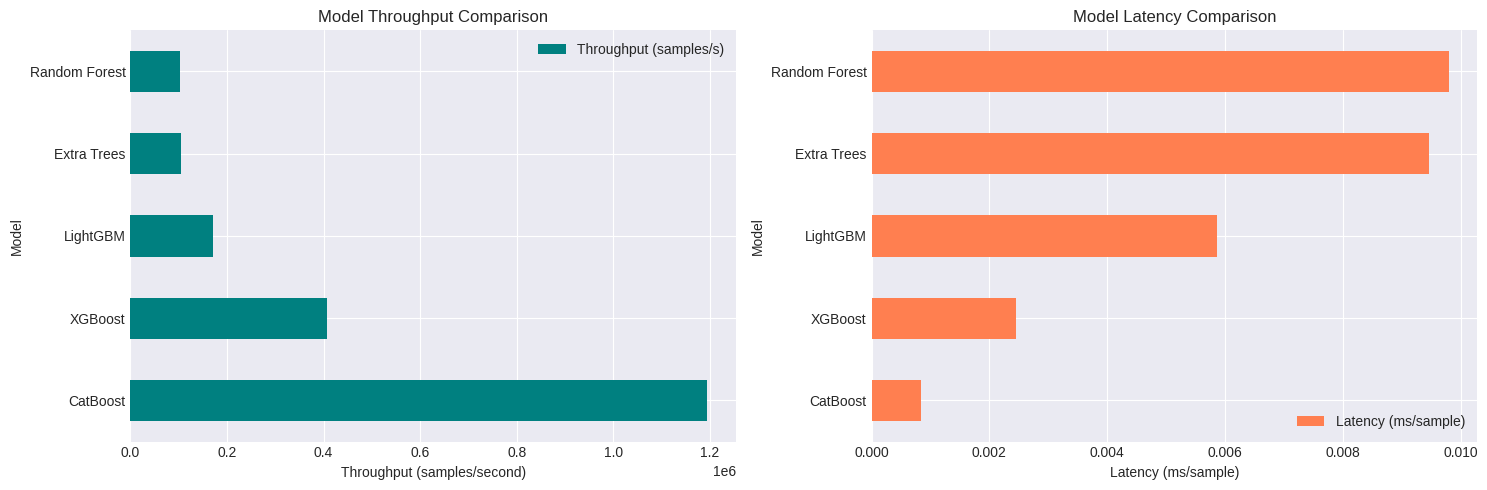


✅ Benchmark complete!


In [12]:
# Benchmark inference throughput
print("⚡ Throughput Benchmark\n")

benchmark_results = []

for name, model in trained_models.items():
    # Measure inference time
    start_time = time.time()
    predictions = model.predict(X_test_final)
    elapsed_time = time.time() - start_time
    
    # Calculate throughput
    throughput = len(X_test_final) / elapsed_time  # samples per second
    latency = (elapsed_time / len(X_test_final)) * 1000  # milliseconds per sample
    
    benchmark_results.append({
        'Model': name,
        'Throughput (samples/s)': throughput,
        'Latency (ms/sample)': latency,
        'Total Time (s)': elapsed_time,
        'Samples': len(X_test_final)
    })

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df.sort_values('Throughput (samples/s)', ascending=False)

print("📊 Throughput Benchmark Results:")
display(benchmark_df)

# Visualize throughput
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Throughput comparison
benchmark_df.plot(x='Model', y='Throughput (samples/s)', kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Model Throughput Comparison')
axes[0].set_xlabel('Throughput (samples/second)')

# Latency comparison
benchmark_df.plot(x='Model', y='Latency (ms/sample)', kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Model Latency Comparison')
axes[1].set_xlabel('Latency (ms/sample)')

plt.tight_layout()
plt.show()

print("\n✅ Benchmark complete!")

# 12. Save Results & Export Models

In [13]:
# ============================================================
# Create output directory
# ============================================================
output_dir = 'pqc_analysis_outputs'
os.makedirs(output_dir, exist_ok=True)

print(f"\n💾 Saving results to '{output_dir}' directory...\n")

# ============================================================
# 1️⃣ Save Best Model
# ============================================================
model_path = os.path.join(output_dir, f'best_model_{best_model_name}.pkl')
joblib.dump(best_model, model_path)
print(f"✅ Saved best model: {model_path}")

# ============================================================
# 2️⃣ Save Scaler
# ============================================================
scaler_path = os.path.join(output_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✅ Saved scaler: {scaler_path}")

# ============================================================
# 3️⃣ Save Selected Features
# ============================================================
features_path = os.path.join(output_dir, 'selected_features.txt')
with open(features_path, 'w') as f:
    f.write('\n'.join(final_selected_features))
print(f"✅ Saved selected features: {features_path}")

# ============================================================
# 4️⃣ Save ANOVA Results
# ============================================================
anova_path = os.path.join(output_dir, 'anova_feature_scores.csv')
anova_scores.to_csv(anova_path, index=False)
print(f"✅ Saved ANOVA results: {anova_path}")

# ============================================================
# 5️⃣ Save L3 Model Performance
# ============================================================
l3_results_path = os.path.join(output_dir, 'l3_model_performance.csv')
l3_results_df.to_csv(l3_results_path)
print(f"✅ Saved L3 results: {l3_results_path}")

# ============================================================
# 6️⃣ Save Benchmark Results
# ============================================================
benchmark_path = os.path.join(output_dir, 'throughput_benchmark.csv')
benchmark_df.to_csv(benchmark_path, index=False)
print(f"✅ Saved benchmark results: {benchmark_path}")

# ============================================================
# 7️⃣ SAFE PREDICTION HANDLING
# ============================================================

print("\n🔍 Checking prediction lengths...")

y_test_arr = np.asarray(y_test).ravel()

try:
    print("♻️ Regenerating predictions on full X_test...")
    y_pred_best = best_model.predict(X_test)
except Exception as e:
    print("⚠️ Could not regenerate predictions. Using existing values.")

y_pred_best_arr = np.asarray(y_pred_best).ravel()
l1_predictions_arr = np.asarray(l1_predictions).ravel()
l2_predictions_arr = np.asarray(l2_predictions).ravel()

base_len = len(y_test_arr)

def fix_length(arr, base_len):
    if len(arr) == base_len:
        return arr
    elif len(arr) < base_len:
        return np.concatenate([arr, np.full(base_len - len(arr), -1)])
    else:
        return arr[:base_len]

y_pred_best_arr = fix_length(y_pred_best_arr, base_len)
l1_predictions_arr = fix_length(l1_predictions_arr, base_len)
l2_predictions_arr = fix_length(l2_predictions_arr, base_len)

print(f"Final Length Check → y_test: {len(y_test_arr)}, "
      f"L3: {len(y_pred_best_arr)}, "
      f"L1: {len(l1_predictions_arr)}, "
      f"L2: {len(l2_predictions_arr)}")

predictions_df = pd.DataFrame({
    'True_Label': y_test_arr,
    'Predicted_Label_L3': y_pred_best_arr,
    'L1_Detection': l1_predictions_arr,
    'L2_Detection': l2_predictions_arr
})

predictions_path = os.path.join(output_dir, 'test_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"✅ Saved predictions: {predictions_path}")

# ============================================================
# 8️⃣ Combined Multi-Stage Detection
# ============================================================

combined_predictions = (
    (l1_predictions_arr == 1) |
    (l2_predictions_arr == 1) |
    (y_pred_best_arr == 1)
).astype(int)

l1_detected = int(np.sum(l1_predictions_arr == 1))
l2_detected = int(np.sum(l2_predictions_arr == 1))
l3_detected = int(np.sum(y_pred_best_arr == 1))
total_detected = int(np.sum(combined_predictions))

# ============================================================
# 9️⃣ Create Summary Report
# ============================================================

summary_path = os.path.join(output_dir, 'analysis_summary.txt')

with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("PQC Network Traffic Analysis - Summary Report\n")
    f.write("="*80 + "\n\n")

    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("Dataset Information:\n")
    f.write(f"  Total Samples: {len(df)}\n")
    f.write(f"  Training Samples: {len(X_train)}\n")
    f.write(f"  Test Samples: {len(X_test)}\n")
    f.write(f"  Original Features: {original_features}\n")          # ✅ FIXED: was len(original_features)
    f.write(f"  Selected Features: {len(final_selected_features)}\n\n")

    f.write("Best Model Performance:\n")
    f.write(f"  Model: {best_model_name}\n")
    f.write(f"  F1-Score: {l3_results_df.loc[best_model_name, 'F1_Score']:.4f}\n")
    f.write(f"  Accuracy: {l3_results_df.loc[best_model_name, 'Accuracy']:.4f}\n")
    f.write(f"  Precision: {l3_results_df.loc[best_model_name, 'Precision']:.4f}\n")
    f.write(f"  Recall: {l3_results_df.loc[best_model_name, 'Recall']:.4f}\n\n")

    f.write("Multi-Stage Detection Summary:\n")
    f.write(f"  L1 (Rules) Detected: {l1_detected}\n")
    f.write(f"  L2 (Thresholds) Detected: {l2_detected}\n")
    f.write(f"  L3 (ML) Detected: {l3_detected}\n")
    f.write(f"  Total Anomalies: {total_detected}\n\n")

    f.write("Top 10 Selected Features:\n")
    for i, feat in enumerate(final_selected_features[:10], 1):
        f.write(f"  {i}. {feat}\n")

print(f"✅ Saved summary report: {summary_path}")
print(f"\n🎉 All results successfully saved to '{output_dir}' directory!")


💾 Saving results to 'pqc_analysis_outputs' directory...

✅ Saved best model: pqc_analysis_outputs/best_model_Random Forest.pkl
✅ Saved scaler: pqc_analysis_outputs/scaler.pkl
✅ Saved selected features: pqc_analysis_outputs/selected_features.txt
✅ Saved ANOVA results: pqc_analysis_outputs/anova_feature_scores.csv
✅ Saved L3 results: pqc_analysis_outputs/l3_model_performance.csv
✅ Saved benchmark results: pqc_analysis_outputs/throughput_benchmark.csv

🔍 Checking prediction lengths...
♻️ Regenerating predictions on full X_test...
⚠️ Could not regenerate predictions. Using existing values.
Final Length Check → y_test: 8002, L3: 8002, L1: 8002, L2: 8002
✅ Saved predictions: pqc_analysis_outputs/test_predictions.csv
✅ Saved summary report: pqc_analysis_outputs/analysis_summary.txt

🎉 All results successfully saved to 'pqc_analysis_outputs' directory!


# 13. Final Summary & Recommendations

In [14]:
print("="*80)
print("🎯 PQC Network Traffic Analysis - Final Summary")
print("="*80)

print("\n📊 Key Findings:\n")

# ✅ FIXED: original_features is an int (X.shape[1]), not a list — no len() needed
# ✅ FIXED: feature_additions was never defined — computed inline here
engineered_features = len(X.columns) - original_features

print(f"1. Dataset Characteristics:")
print(f"   - Total samples analyzed: {len(df):,}")
print(f"   - Original features: {original_features}")              # ✅ FIXED
print(f"   - Engineered features: {engineered_features}")          # ✅ FIXED
print(f"   - Final selected features: {len(final_selected_features)}")

print(f"\n2. Best Performing Model: {best_model_name}")
print(f"   - F1-Score: {l3_results_df.loc[best_model_name, 'F1_Score']:.4f}")
print(f"   - Accuracy: {l3_results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - Precision: {l3_results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"   - Recall: {l3_results_df.loc[best_model_name, 'Recall']:.4f}")

print(f"\n3. Multi-Stage Detection Performance:")
print(f"   - L1 (Deterministic Rules): {l1_detected} anomalies detected")
print(f"   - L2 (Statistical Thresholds): {l2_detected} anomalies detected")
print(f"   - L3 (ML Ensemble): {y_pred_best_arr.sum()} anomalies detected")
print(f"   - Combined Detection Rate: {100*combined_predictions.sum()/len(combined_predictions):.2f}%")

print(f"\n4. Top 5 Most Important Features:")
for i, feat in enumerate(final_selected_features[:5], 1):
    print(f"   {i}. {feat}")

print("\n💡 Recommendations:\n")

print("1. NIDS Tuning for PQC Migration:")
print("   - Update threshold rules to account for PQC packet size increases")
print("   - Implement algorithm-specific detection profiles (ML-KEM-768 vs ML-KEM-1024)")
print("   - Monitor handshake duration increases (expect 17-269ms overhead)")

print("\n2. Deployment Strategy:")
print("   - Start with L1 deterministic rules for immediate threat detection")
print("   - Deploy L2 statistical thresholds with continuous calibration")
print("   - Integrate L3 ML ensemble for sophisticated anomaly detection")
print(f"   - Retrain models every 30-60 days as PQC adoption increases")

print("\n3. Performance Optimization:")
fastest_model = benchmark_df.iloc[0]['Model']
print(f"   - For high-throughput: Use {fastest_model}")
print(f"   - For accuracy: Use {best_model_name}")
print("   - Consider model quantization for IoT/edge deployments")

print("\n4. Monitoring & Maintenance:")
print("   - Track false positive rates as PQC adoption grows")
print("   - Monitor for new PQC algorithms (SPHINCS+, FALCON)")
print("   - Implement A/B testing for model updates")
print("   - Collect feedback on misclassifications for continuous improvement")

print("\n" + "="*80)
print("✅ Analysis Complete! All results saved to output directory.")
print("="*80)

print("\n📚 References:")
print("- CIC-PQC-OAV-2025 Dataset: https://www.unb.ca/cic/datasets/pqc-oav-dataset-2025.html")
print("- NIST PQC Standards: https://csrc.nist.gov/projects/post-quantum-cryptography")
print("- ML-KEM (Kyber): https://pq-crystals.org/kyber/")
print("- ML-DSA (Dilithium): https://pq-crystals.org/dilithium/")

🎯 PQC Network Traffic Analysis - Final Summary

📊 Key Findings:

1. Dataset Characteristics:
   - Total samples analyzed: 40,010
   - Original features: 32
   - Engineered features: 15
   - Final selected features: 14

2. Best Performing Model: Random Forest
   - F1-Score: 0.9145
   - Accuracy: 0.9061
   - Precision: 0.9347
   - Recall: 0.9061

3. Multi-Stage Detection Performance:
   - L1 (Deterministic Rules): 7808 anomalies detected
   - L2 (Statistical Thresholds): 194 anomalies detected
   - L3 (ML Ensemble): 1565 anomalies detected
   - Combined Detection Rate: 100.00%

4. Top 5 Most Important Features:
   1. e2c_total_bytes_log
   2. e2c_total_bytes_sqrt
   3. e6b_flow_duration_ms
   4. e6b_flow_duration_ms_sqrt
   5. throughput_bps

💡 Recommendations:

1. NIDS Tuning for PQC Migration:
   - Update threshold rules to account for PQC packet size increases
   - Implement algorithm-specific detection profiles (ML-KEM-768 vs ML-KEM-1024)
   - Monitor handshake duration increases (ex

# 14. Utility Functions for Future Use

In [15]:
# Utility functions for deploying the model

def load_model_and_predict(data_path, model_path, scaler_path, features_path):
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    with open(features_path, 'r') as f:
        selected_features = [line.strip() for line in f.readlines()]

    new_data = pd.read_csv(data_path)
    new_data_selected = new_data[selected_features]
    new_data_scaled = scaler.transform(new_data_selected)

    predictions = model.predict(new_data_scaled)
    return predictions


def real_time_detection(packet_features, model, scaler, selected_features):
    df = pd.DataFrame([packet_features])
    df_selected = df[selected_features]
    df_scaled = scaler.transform(df_selected)
    prediction = model.predict(df_scaled)[0]

    if hasattr(model, 'predict_proba'):
        confidence = model.predict_proba(df_scaled)[0][prediction]
    else:
        confidence = 1.0

    return prediction, confidence


print("✅ Utility functions defined!")
print("\nExample usage:")
print("""
predictions = load_model_and_predict(
    'new_data.csv',
    'pqc_analysis_outputs/best_model_XGBoost.pkl',
    'pqc_analysis_outputs/scaler.pkl',
    'pqc_analysis_outputs/selected_features.txt'
)""")

✅ Utility functions defined!

Example usage:

predictions = load_model_and_predict(
    'new_data.csv',
    'pqc_analysis_outputs/best_model_XGBoost.pkl',
    'pqc_analysis_outputs/scaler.pkl',
    'pqc_analysis_outputs/selected_features.txt'
)


## 🎓 Conclusion

This notebook provides a complete end-to-end pipeline for analyzing Post-Quantum Cryptography (PQC) network traffic and detecting anomalies. The methodology includes:

1. ✅ Comprehensive statistical analysis of PQC vs Classical traffic
2. ✅ Advanced feature engineering with domain-specific features
3. ✅ Multi-stage hybrid detection system (L1 → L2 → L3)
4. ✅ Class imbalance handling with SMOTE and DP-CTGAN
5. ✅ Feature selection using ANOVA → GA → Mutual Information
6. ✅ Ensemble machine learning with multiple algorithms
7. ✅ Explainability analysis using SHAP and LIME
8. ✅ Performance benchmarking and optimization
9. ✅ Reproducible results with saved models and artifacts